## 1. 미션 범위와 목표

- 과제 목표: 한국어 문장을 영어 문장으로 번역하는 모델 구축
- 필수 모델: `Seq2Seq(GRU)`와 `Seq2Seq + Attention`
- 선택 모델: 시간 여유가 있을 때 `Transformer` 추가 실험
- 최종 목표: 정량/정성 평가를 통해 모델 성능을 비교하고 결론 도출


In [1]:
import random
import numpy as np
import torch
from pathlib import Path

# 1) 재현성 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 2) 실행 장치 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3) 미션 공통 설정(비교 실험 기준)
CFG = {
    "seed": SEED,
    "src_lang": "ko",
    "tgt_lang": "en",
    "required_models": ["seq2seq_gru", "seq2seq_attention"],
    "optional_models": ["transformer"],
    "max_length_policy": "p95_train_lengths",
    "batch_size": 64,
    "fast_experiment": True,
    "fast_train_ratio": 0.02,
    "fast_valid_ratio": 0.02,
    "fast_max_src_len": 14,
    "fast_max_tgt_len": 18,
    "epochs": 3,
    "learning_rate": 1e-3,
    "teacher_forcing_ratio": 0.5,
    "patience": 2,
    "metrics": ["train_loss", "valid_loss", "bleu_optional"]
}

# 4) 데이터 경로(현재 로컬 프로젝트 기준)
CONTENT_DIR = Path("./content/일상생활및구어체_한영")
DATA_PATHS = {
    "train_json": str(CONTENT_DIR / "일상생활및구어체_한영_train_set.json"),
    "valid_json": str(CONTENT_DIR / "일상생활및구어체_한영_valid_set.json"),
}

# 5) 진행 체크리스트
MISSION_CHECKLIST = [
    "JSON 데이터셋 로드(ko, mt)",
    "한/영 토큰화 및 전처리",
    "어휘 사전(vocab) 구축 및 인덱스 변환",
    "Seq2Seq / Attention 모델 학습",
    "정량/정성 평가 수행",
    "모델 비교 및 최종 결론 정리"
]

print("[1단계] 미션 기본 설정 완료")
print(f"- 실행 장치: {device}")
print(f"- 필수 모델: {CFG['required_models']}")
print(f"- 배치 크기 / 에폭: {CFG['batch_size']} / {CFG['epochs']}")
print(f"- Teacher Forcing 비율: {CFG['teacher_forcing_ratio']}")
print(f"- 훈련 데이터 경로: {DATA_PATHS['train_json']}")
print(f"- 검증 데이터 경로: {DATA_PATHS['valid_json']}")
print("\n[체크리스트]")
for i, item in enumerate(MISSION_CHECKLIST, start=1):
    print(f"{i}. [ ] {item}")


[1단계] 미션 기본 설정 완료
- 실행 장치: cuda
- 필수 모델: ['seq2seq_gru', 'seq2seq_attention']
- 배치 크기 / 에폭: 64 / 3
- Teacher Forcing 비율: 0.5
- 훈련 데이터 경로: content\일상생활및구어체_한영\일상생활및구어체_한영_train_set.json
- 검증 데이터 경로: content\일상생활및구어체_한영\일상생활및구어체_한영_valid_set.json

[체크리스트]
1. [ ] JSON 데이터셋 로드(ko, mt)
2. [ ] 한/영 토큰화 및 전처리
3. [ ] 어휘 사전(vocab) 구축 및 인덱스 변환
4. [ ] Seq2Seq / Attention 모델 학습
5. [ ] 정량/정성 평가 수행
6. [ ] 모델 비교 및 최종 결론 정리


## 2. 실험 설계 고정(공정 비교 기준)

모델 간 성능 비교의 공정성을 위해 다음 조건을 고정합니다.

- 동일한 토크나이저 및 전처리 규칙 사용
- 동일한 train/valid 분할 전략 사용
- 동일한 `MAX_LENGTH` 설정 기준 사용
- 동일한 학습 조건(optimizer, batch size, epoch 등) 유지
- 핵심 비교에서는 모델 구조(Attention 유무)만 변경


[폰트 설정] 사용 폰트: Malgun Gothic
[2단계] 데이터 로드 + EDA 완료
- 훈련 샘플 수 (원본 -> 정제): 1,200,000 -> 24,000
- 검증 샘플 수 (원본 -> 정제): 150,000 -> 3,000
- 제안 MAX_LENGTH (p95 기반): 22

[훈련 데이터 길이 통계 | 한국어]
  mean: 6.54
  median: 6.00
  p95: 13.00
  p99: 18.00
  max: 46

[훈련 데이터 길이 통계 | 영어]
  mean: 9.84
  median: 9.00
  p95: 20.00
  p99: 26.01
  max: 65


,ko,mt
0,>많이 나갔으니까.,> Because I've been out a lot.
1,">바꿀 기회 줘요, 말아요?",>Do you want me to change it or not?
2,">하나, 둘, 셋, 넷, 다섯.",">One, two, three, four, five."


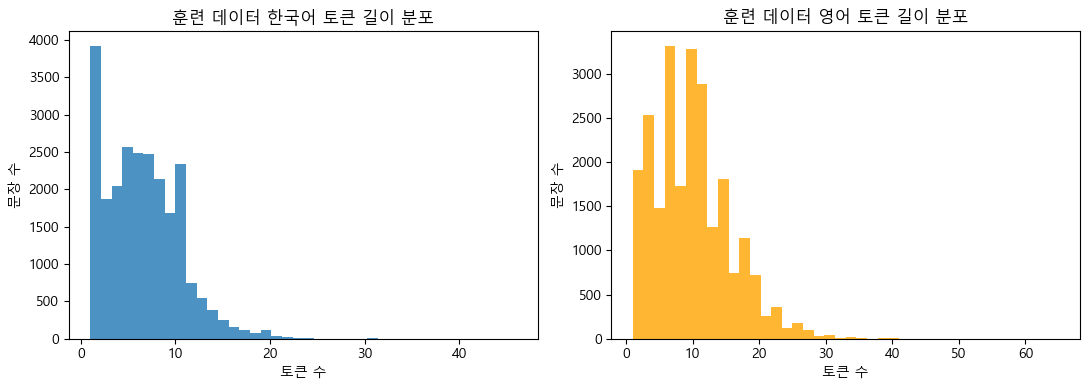


- train_pairs: 24,000, valid_pairs: 3,000


In [2]:
# STEP2_DATA_EDA
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings

# 그래프 한글 폰트 설정 (Windows/Mac/Linux 공통 후보)
font_candidates = ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"]
available_fonts = {f.name for f in fm.fontManager.ttflist}
selected_font = next((f for f in font_candidates if f in available_fonts), None)

if selected_font is not None:
    plt.rcParams["font.family"] = selected_font
    plt.rcParams["axes.unicode_minus"] = False
    print(f"[폰트 설정] 사용 폰트: {selected_font}")
else:
    # 폰트가 없으면 경고만 숨기고(로그 과다 방지), 라벨은 가능하면 영문 사용 권장
    warnings.filterwarnings("ignore", message="Glyph .* missing from font")
    print("[폰트 설정] 한글 폰트를 찾지 못했습니다. 필요 시 Malgun Gothic/NanumGothic 설치 권장")


def _load_json_records(path: Path):
    with path.open('r', encoding='utf-8') as f:
        obj = json.load(f)

    if isinstance(obj, list):
        records = obj
    elif isinstance(obj, dict):
        # dict 구조면 data 키를 우선 사용
        if 'data' in obj and isinstance(obj['data'], list):
            records = obj['data']
        else:
            # 그 외에는 list 타입 값을 찾아 사용
            records = None
            for v in obj.values():
                if isinstance(v, list):
                    records = v
                    break
            if records is None:
                raise ValueError(f'지원하지 않는 JSON 구조: {path}')
    else:
        raise ValueError(f'지원하지 않는 JSON 타입: {type(obj)} in {path}')

    df = pd.DataFrame(records)
    required_cols = {'ko', 'mt'}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"필수 컬럼 {required_cols} 이(가) 없습니다. 현재 컬럼: {set(df.columns)}")

    return df[['ko', 'mt']].copy()

# 1) 데이터 경로 확인
train_path = Path(DATA_PATHS['train_json'])
valid_path = Path(DATA_PATHS['valid_json'])

if not train_path.exists() or not valid_path.exists():
    raise FileNotFoundError(
        '1단계 DATA_PATHS를 먼저 수정하세요. '
        f'train={train_path} exists={train_path.exists()}, '
        f'valid={valid_path} exists={valid_path.exists()}'
    )

# 2) 원본 데이터 로드
train_df_raw = _load_json_records(train_path)
valid_df_raw = _load_json_records(valid_path)

# 3) 기본 정제: 공백 제거 + 빈 문장 제거
def _clean_text_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['ko'] = out['ko'].astype(str).str.strip()
    out['mt'] = out['mt'].astype(str).str.strip()
    out = out[(out['ko'] != '') & (out['mt'] != '')].reset_index(drop=True)
    return out

train_df = _clean_text_df(train_df_raw)
valid_df = _clean_text_df(valid_df_raw)

# ?? ?? ??: ?? ??? ??? ???
if bool(CFG.get("fast_experiment", False)):
    tr_frac = float(CFG.get("fast_train_ratio", 0.02))
    va_frac = float(CFG.get("fast_valid_ratio", 0.02))
    tr_n = max(1, int(len(train_df) * tr_frac))
    va_n = max(1, int(len(valid_df) * va_frac))
    train_df = train_df.sample(n=tr_n, random_state=CFG.get("seed", 42)).reset_index(drop=True)
    valid_df = valid_df.sample(n=va_n, random_state=CFG.get("seed", 42)).reset_index(drop=True)
    CFG["fast_train_size"] = len(train_df)
    CFG["fast_valid_size"] = len(valid_df)

# 4) 문장 길이 통계(공백 기준 토큰 수)
train_df['ko_tok_len'] = train_df['ko'].str.split().str.len()
train_df['mt_tok_len'] = train_df['mt'].str.split().str.len()
valid_df['ko_tok_len'] = valid_df['ko'].str.split().str.len()
valid_df['mt_tok_len'] = valid_df['mt'].str.split().str.len()

def _describe_len(arr):
    arr = np.asarray(arr)
    return {
        'mean': float(arr.mean()),
        'median': float(np.median(arr)),
        'p95': float(np.percentile(arr, 95)),
        'p99': float(np.percentile(arr, 99)),
        'max': int(arr.max()),
    }

ko_stats = _describe_len(train_df['ko_tok_len'])
mt_stats = _describe_len(train_df['mt_tok_len'])

# 5) MAX_LENGTH 제안값 (p95 기반 + SOS/EOS 2칸)
suggested_max_len = int(max(ko_stats['p95'], mt_stats['p95']) + 2)
MAX_LENGTH = suggested_max_len
CFG['max_length'] = MAX_LENGTH

print('[2단계] 데이터 로드 + EDA 완료')
print(f"- 훈련 샘플 수 (원본 -> 정제): {len(train_df_raw):,} -> {len(train_df):,}")
print(f"- 검증 샘플 수 (원본 -> 정제): {len(valid_df_raw):,} -> {len(valid_df):,}")
print(f"- 제안 MAX_LENGTH (p95 기반): {MAX_LENGTH}")

print('\n[훈련 데이터 길이 통계 | 한국어]')
for k, v in ko_stats.items():
    print(f"  {k}: {v:.2f}" if isinstance(v, float) else f"  {k}: {v}")

print('\n[훈련 데이터 길이 통계 | 영어]')
for k, v in mt_stats.items():
    print(f"  {k}: {v:.2f}" if isinstance(v, float) else f"  {k}: {v}")

display(train_df[['ko', 'mt']].head(3))

# 길이 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(train_df['ko_tok_len'], bins=40, alpha=0.8)
axes[0].set_title('훈련 데이터 한국어 토큰 길이 분포')
axes[0].set_xlabel('토큰 수')
axes[0].set_ylabel('문장 수')

axes[1].hist(train_df['mt_tok_len'], bins=40, alpha=0.8, color='orange')
axes[1].set_title('훈련 데이터 영어 토큰 길이 분포')
axes[1].set_xlabel('토큰 수')
axes[1].set_ylabel('문장 수')

plt.tight_layout()
plt.show()

# 다음 단계에서 바로 사용할 문장쌍
train_pairs = list(zip(train_df['ko'].tolist(), train_df['mt'].tolist()))
valid_pairs = list(zip(valid_df['ko'].tolist(), valid_df['mt'].tolist()))
print(f"\n- train_pairs: {len(train_pairs):,}, valid_pairs: {len(valid_pairs):,}")


## 3. 데이터셋 소개 및 EDA 계획

- JSON 스키마 확인: 입력 `ko`, 정답 번역 `mt`
- 학습/검증 데이터 샘플 수 점검
- 한/영 문장 길이 분포 분석(평균, 중앙값, 상위 백분위)
- 결측/빈문장/극단적 길이(outlier) 처리 기준 정의
- EDA 결과를 바탕으로 `MAX_LENGTH` 근거 제시


In [3]:
# STEP3_DATASET_OVERVIEW
import pandas as pd
import numpy as np

# 2번 셀 선행 실행 확인
required_vars = ["train_df", "valid_df", "MAX_LENGTH", "train_pairs", "valid_pairs"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"2번 셀을 먼저 실행하세요. 누락 변수: {missing}")

# 1) 데이터셋 기본 요약
dataset_summary = pd.DataFrame([
    {
        "split": "train",
        "샘플수": len(train_df),
        "ko_평균길이": float(train_df["ko_tok_len"].mean()),
        "mt_평균길이": float(train_df["mt_tok_len"].mean()),
        "ko_p95": float(np.percentile(train_df["ko_tok_len"], 95)),
        "mt_p95": float(np.percentile(train_df["mt_tok_len"], 95)),
    },
    {
        "split": "valid",
        "샘플수": len(valid_df),
        "ko_평균길이": float(valid_df["ko_tok_len"].mean()),
        "mt_평균길이": float(valid_df["mt_tok_len"].mean()),
        "ko_p95": float(np.percentile(valid_df["ko_tok_len"], 95)),
        "mt_p95": float(np.percentile(valid_df["mt_tok_len"], 95)),
    },
])

print("[3단계] 데이터셋 소개/EDA 상세 점검 완료")
display(dataset_summary)

# 2) 길이 구간별 비율 확인(훈련셋 기준)
def _bucket_ratio(series):
    s = series.astype(int)
    total = len(s)
    buckets = {
        "<=10": (s <= 10).sum(),
        "11~20": ((s > 10) & (s <= 20)).sum(),
        "21~40": ((s > 20) & (s <= 40)).sum(),
        "41~80": ((s > 40) & (s <= 80)).sum(),
        "81~160": ((s > 80) & (s <= 160)).sum(),
        "161~320": ((s > 160) & (s <= 320)).sum(),
        ">320": (s > 320).sum(),
    }
    return {k: v / total for k, v in buckets.items()}

ko_bucket = _bucket_ratio(train_df["ko_tok_len"])
mt_bucket = _bucket_ratio(train_df["mt_tok_len"])

bucket_df = pd.DataFrame({
    "구간": list(ko_bucket.keys()),
    "ko_비율": [ko_bucket[k] for k in ko_bucket.keys()],
    "mt_비율": [mt_bucket[k] for k in mt_bucket.keys()],
})

print("\n[훈련 데이터 길이 구간 비율]")
display(bucket_df)

# 3) 긴 문장 샘플 확인(아웃라이어 점검)
long_ko_examples = train_df.nlargest(3, "ko_tok_len")[["ko", "mt", "ko_tok_len", "mt_tok_len"]]
long_mt_examples = train_df.nlargest(3, "mt_tok_len")[["ko", "mt", "ko_tok_len", "mt_tok_len"]]

print("\n[KO 기준 긴 문장 상위 3개]")
display(long_ko_examples)
print("\n[MT 기준 긴 문장 상위 3개]")
display(long_mt_examples)

# 4) MAX_LENGTH 커버리지 확인 (+2는 SOS/EOS 여유)
ko_coverage = ((train_df["ko_tok_len"] + 2) <= MAX_LENGTH).mean()
mt_coverage = ((train_df["mt_tok_len"] + 2) <= MAX_LENGTH).mean()

print("\n[MAX_LENGTH 커버리지 점검]")
print(f"- 현재 MAX_LENGTH: {MAX_LENGTH}")
print(f"- KO 커버리지: {ko_coverage*100:.2f}%")
print(f"- MT 커버리지: {mt_coverage*100:.2f}%")

# 5) 리포트용 요약 값 저장(이후 마크다운 분석에 활용)
EDA_REPORT = {
    "train_size": len(train_df),
    "valid_size": len(valid_df),
    "max_length": MAX_LENGTH,
    "ko_coverage": float(ko_coverage),
    "mt_coverage": float(mt_coverage),
}
print("\n- EDA_REPORT 저장 완료:", EDA_REPORT)


[3단계] 데이터셋 소개/EDA 상세 점검 완료


,split,샘플수,ko_평균길이,mt_평균길이,ko_p95,mt_p95
0,train,24000,6.540792,9.837542,13.0,20.0
1,valid,3000,6.512667,9.816000,13.0,20.0



[훈련 데이터 길이 구간 비율]


,구간,ko_비율,mt_비율
0,<=10,0.853333,0.594458
1,11~20,0.142750,0.357292
2,21~40,0.003792,0.047958
3,41~80,0.000125,0.000292
4,81~160,0.000000,0.000000
5,161~320,0.000000,0.000000
6,>320,0.000000,0.000000



[KO 기준 긴 문장 상위 3개]


,ko,mt,ko_tok_len,mt_tok_len
11109,>이 영상을 보고 따라하고 뭐 하면 노래가 쉽게 뜰 수 있는 거죠 요즘에는 요런 플...,">If you watch this video and copy it, the song...",46,63
11692,모든 지구경을 위한 평생 구충제 맥스가드 스펙트라 당신의 마지막 모험은 언제였는가 ...,"Maxgard Spectra, a lifelong anthelmintic for a...",46,65
8470,>이게 뭐 예를 들어서 한창 이제 지금보다 예전에는 한국에도 앨범을 내고 일본에도 ...,">For example, in the past, I released albums i...",41,40



[MT 기준 긴 문장 상위 3개]


,ko,mt,ko_tok_len,mt_tok_len
11692,모든 지구경을 위한 평생 구충제 맥스가드 스펙트라 당신의 마지막 모험은 언제였는가 ...,"Maxgard Spectra, a lifelong anthelmintic for a...",46,65
11109,>이 영상을 보고 따라하고 뭐 하면 노래가 쉽게 뜰 수 있는 거죠 요즘에는 요런 플...,">If you watch this video and copy it, the song...",46,63
2401,왜냐하면 어머니 계셨는데 어머니는 지방에 장사하러 다니셔서 겨울방학 때만 만났거든요...,"Because my mother was there, and I met her onl...",37,58



[MAX_LENGTH 커버리지 점검]
- 현재 MAX_LENGTH: 22
- KO 커버리지: 99.61%
- MT 커버리지: 95.17%

- EDA_REPORT 저장 완료: {'train_size': 24000, 'valid_size': 3000, 'max_length': 22, 'ko_coverage': 0.9960833333333333, 'mt_coverage': 0.95175}


## 4. 전처리 및 토크나이징 전략

- 한국어/영어 각각에 맞는 정규화 규칙 정의
- 사용할 토크나이저와 선택 이유 기록
- 특수 토큰 정의: `SOS`, `EOS`, `PAD`, `UNK`
- 기본 전처리와 추가 전처리(선택 실험)를 분리해 관리


In [4]:
# STEP4_PREPROCESS_TOKENIZE
import re
import unicodedata
import numpy as np

# 1) 2번 셀에서 만든 필수 변수들이 존재하는지 확인
required_vars = ["train_df", "valid_df", "MAX_LENGTH"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"2번 셀을 먼저 실행하세요. 누락 변수: {missing}")

# 2) 특수 토큰 정의
#    이후 5~7번 단계에서 재사용
SPECIAL_TOKENS = {
    "PAD": "<pad>",
    "SOS": "<sos>",
    "EOS": "<eos>",
    "UNK": "<unk>",
}

# 3) 사용할 토크나이저 방식 설명
TOKENIZER_INFO = {
    "ko": "공백 기반 + 기본 정규화",
    "en": "소문자 + 공백 기반 + 기본 정규화",
}

# 4) 한국어 텍스트 정규화 함수
#    - 유니코드 정규화
#    - 불필요한 특수문자 제거
#    - 문장부호 주변 공백 정리
def normalize_ko_text(text: str) -> str:
    text = unicodedata.normalize("NFKC", str(text))
    text = text.strip()
    text = re.sub(r"[^가-힣a-zA-Z0-9\s\.,!;:\-]", " ", text)
    text = re.sub(r"([\.,!;:])", r" \1 ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# 5) 영어 텍스트 정규화 함수
#    - 소문자 변환
#    - 유니코드 정규화
#    - 불필요한 특수문자 제거
#    - 문장부호 주변 공백 정리
def normalize_en_text(text: str) -> str:
    text = unicodedata.normalize("NFKC", str(text))
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9\s\.,!;:\-]", " ", text)
    text = re.sub(r"([\.,!;:])", r" \1 ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# 6) 한국어 토큰화 함수
#    정규화 후 공백 기준으로 분리
def tokenize_ko(text: str):
    return normalize_ko_text(text).split()

# 7) 영어 토큰화 함수
#    정규화 후 공백 기준으로 분리
def tokenize_en(text: str):
    return normalize_en_text(text).split()

# 8) train/valid 데이터프레임에 정규화된 텍스트 컬럼 추가
train_df["ko_norm"] = train_df["ko"].apply(normalize_ko_text)
train_df["mt_norm"] = train_df["mt"].apply(normalize_en_text)
valid_df["ko_norm"] = valid_df["ko"].apply(normalize_ko_text)
valid_df["mt_norm"] = valid_df["mt"].apply(normalize_en_text)

# 9) 정규화된 문장을 토큰 리스트로 변환
train_src_tokens = train_df["ko_norm"].apply(tokenize_ko).tolist()
train_tgt_tokens = train_df["mt_norm"].apply(tokenize_en).tolist()
valid_src_tokens = valid_df["ko_norm"].apply(tokenize_ko).tolist()
valid_tgt_tokens = valid_df["mt_norm"].apply(tokenize_en).tolist()

# 10) 학습 데이터 기준 토큰 길이 통계 계산
train_src_lens = np.array([len(x) for x in train_src_tokens])
train_tgt_lens = np.array([len(x) for x in train_tgt_tokens])

# 11) p95 기준으로 최대 길이 설정
#     +2는 SOS/EOS 토큰 여유분
MAX_SRC_LEN = int(np.percentile(train_src_lens, 95)) + 2
MAX_TGT_LEN = int(np.percentile(train_tgt_lens, 95)) + 2

# 12) 빠른 실험 모드일 경우 최대 길이를 더 작게 제한
#     학습 속도와 메모리 사용량을 줄이기 위한 설정
if bool(CFG.get("fast_experiment", False)):
    MAX_SRC_LEN = min(MAX_SRC_LEN, int(CFG.get("fast_max_src_len", 14)))
    MAX_TGT_LEN = min(MAX_TGT_LEN, int(CFG.get("fast_max_tgt_len", 18)))

# 13) 기존 MAX_LENGTH와 비교해서 가장 보수적인 최종 길이 사용
MAX_LENGTH = max(MAX_LENGTH, MAX_SRC_LEN, MAX_TGT_LEN)
CFG["max_length"] = MAX_LENGTH
CFG["max_src_len"] = MAX_SRC_LEN
CFG["max_tgt_len"] = MAX_TGT_LEN

# 14) 현재 최대 길이가 학습 데이터의 몇 퍼센트를 커버하는지 확인
src_coverage = ((train_src_lens + 2) <= MAX_LENGTH).mean()
tgt_coverage = ((train_tgt_lens + 2) <= MAX_LENGTH).mean()

# 15) 전처리 및 길이 설정 결과 출력
print("[4단계] 전처리/토크나이징 완료")
print(f"- 토크나이저(ko): {TOKENIZER_INFO['ko']}")
print(f"- 토크나이저(en): {TOKENIZER_INFO['en']}")
print(f"- MAX_SRC_LEN(p95+2): {MAX_SRC_LEN}")
print(f"- MAX_TGT_LEN(p95+2): {MAX_TGT_LEN}")
print(f"- 최종 MAX_LENGTH: {MAX_LENGTH}")
print(f"- SRC 커버리지: {src_coverage*100:.2f}%")
print(f"- TGT 커버리지: {tgt_coverage*100:.2f}%")

# 16) 토큰화 예시 출력
print("\n[토큰화 예시 2개]")
for i in range(2):
    print(f"- 원문 KO: {train_df.iloc[i]['ko']}")
    print(f"  토큰 KO: {train_src_tokens[i][:20]}")
    print(f"  원문 EN: {train_df.iloc[i]['mt']}")
    print(f"  토큰 EN: {train_tgt_tokens[i][:20]}")

# 17) 이후 단계에서 사용할 (입력 토큰, 출력 토큰) 쌍 생성
train_token_pairs = list(zip(train_src_tokens, train_tgt_tokens))
valid_token_pairs = list(zip(valid_src_tokens, valid_tgt_tokens))

# 18) 생성된 데이터 개수 확인
print(f"\n- train_token_pairs: {len(train_token_pairs):,}")
print(f"- valid_token_pairs: {len(valid_token_pairs):,}")

[4단계] 전처리/토크나이징 완료
- 토크나이저(ko): 공백 기반 + 기본 정규화
- 토크나이저(en): 소문자 + 공백 기반 + 기본 정규화
- MAX_SRC_LEN(p95+2): 14
- MAX_TGT_LEN(p95+2): 18
- 최종 MAX_LENGTH: 22
- SRC 커버리지: 99.10%
- TGT 커버리지: 91.52%

[토큰화 예시 2개]
- 원문 KO: >많이 나갔으니까.
  토큰 KO: ['많이', '나갔으니까', '.']
  원문 EN: > Because I've been out a lot.
  토큰 EN: ['because', 'i', 've', 'been', 'out', 'a', 'lot', '.']
- 원문 KO: >바꿀 기회 줘요, 말아요?
  토큰 KO: ['바꿀', '기회', '줘요', ',', '말아요']
  원문 EN: >Do you want me to change it or not?
  토큰 EN: ['do', 'you', 'want', 'me', 'to', 'change', 'it', 'or', 'not']

- train_token_pairs: 24,000
- valid_token_pairs: 3,000


## 5. 어휘 사전(Vocab) 구축 전략

- 한국어/영어 어휘 사전을 분리하여 구축
- `token2idx`, `idx2token` 매핑 규칙 정의
- 최소 등장 빈도(min frequency) 기준 사용 여부 명시
- UNK 처리 정책과 최종 vocab 크기 보고


In [5]:
# STEP5_VOCAB_BUILD
from collections import Counter
import pandas as pd

# 1) 4번 셀에서 만든 필수 변수들이 존재하는지 확인
required_vars = [
    "train_src_tokens", "train_tgt_tokens",
    "valid_src_tokens", "valid_tgt_tokens",
    "SPECIAL_TOKENS"
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"4번 셀을 먼저 실행하세요. 누락 변수: {missing}")

# 2) 최소 등장 빈도 설정
#    너무 드물게 등장하는 토큰은 vocab에서 제외하기 위한 기준
SRC_MIN_FREQ = 2
TGT_MIN_FREQ = 2
CFG["src_min_freq"] = SRC_MIN_FREQ
CFG["tgt_min_freq"] = TGT_MIN_FREQ

# 3) 특수 토큰 순서와 인덱스 고정
#    PAD: 패딩, SOS: 시작, EOS: 종료, UNK: 미등록 토큰
SPECIAL_ORDER = [
    SPECIAL_TOKENS["PAD"],
    SPECIAL_TOKENS["SOS"],
    SPECIAL_TOKENS["EOS"],
    SPECIAL_TOKENS["UNK"],
]

PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
UNK_IDX = 3

# 4) 토큰 리스트로부터 vocab을 만드는 함수 정의
#    - 토큰 빈도 계산
#    - min_freq 이상만 선택
#    - 재현성을 위해 정렬
#    - 특수 토큰을 먼저 넣고 나머지 토큰에 인덱스 부여
def build_vocab(token_lists, min_freq=1):
    counter = Counter(tok for sent in token_lists for tok in sent)
    vocab_tokens = [tok for tok, cnt in counter.items() if cnt >= min_freq]
    vocab_tokens = sorted(vocab_tokens)

    token2idx = {tok: i for i, tok in enumerate(SPECIAL_ORDER)}
    for tok in vocab_tokens:
        if tok not in token2idx:
            token2idx[tok] = len(token2idx)

    idx2token = {idx: tok for tok, idx in token2idx.items()}
    return token2idx, idx2token, counter

# 5) 학습 데이터 기준으로 source / target vocab 구축
src_token2idx, src_idx2token, src_counter = build_vocab(train_src_tokens, min_freq=SRC_MIN_FREQ)
tgt_token2idx, tgt_idx2token, tgt_counter = build_vocab(train_tgt_tokens, min_freq=TGT_MIN_FREQ)

# 6) 검증 데이터에서 OOV 비율을 계산하는 함수 정의
#    OOV(Out-Of-Vocabulary): vocab에 없는 토큰 비율
def oov_ratio(token_lists, token2idx):
    total = 0
    oov = 0
    for sent in token_lists:
        for tok in sent:
            total += 1
            if tok not in token2idx:
                oov += 1
    return (oov / total) if total > 0 else 0.0

# 7) 검증셋 기준 source / target OOV 비율 계산
src_valid_oov = oov_ratio(valid_src_tokens, src_token2idx)
tgt_valid_oov = oov_ratio(valid_tgt_tokens, tgt_token2idx)

# 8) 이후 단계에서 재사용할 설정값을 CFG에 저장
CFG["src_vocab_size"] = len(src_token2idx)
CFG["tgt_vocab_size"] = len(tgt_token2idx)
CFG["pad_idx"] = PAD_IDX
CFG["sos_idx"] = SOS_IDX
CFG["eos_idx"] = EOS_IDX
CFG["unk_idx"] = UNK_IDX

# 9) vocab 구축 결과 출력
print("[5단계] 어휘 사전 구축 완료")
print(f"- SRC vocab 크기: {len(src_token2idx):,} (min_freq={SRC_MIN_FREQ})")
print(f"- TGT vocab 크기: {len(tgt_token2idx):,} (min_freq={TGT_MIN_FREQ})")
print(f"- PAD/SOS/EOS/UNK 인덱스: {PAD_IDX}/{SOS_IDX}/{EOS_IDX}/{UNK_IDX}")
print(f"- 검증셋 SRC OOV 비율: {src_valid_oov*100:.2f}%")
print(f"- 검증셋 TGT OOV 비율: {tgt_valid_oov*100:.2f}%")

# 10) 가장 자주 등장한 토큰 상위 20개 확인
src_top20 = src_counter.most_common(20)
tgt_top20 = tgt_counter.most_common(20)
display(pd.DataFrame(src_top20, columns=["src_token", "count"]))
display(pd.DataFrame(tgt_top20, columns=["tgt_token", "count"]))

[5단계] 어휘 사전 구축 완료
- SRC vocab 크기: 14,511 (min_freq=2)
- TGT vocab 크기: 7,415 (min_freq=2)
- PAD/SOS/EOS/UNK 인덱스: 0/1/2/3
- 검증셋 SRC OOV 비율: 24.20%
- 검증셋 TGT OOV 비율: 3.59%


,src_token,count
0,.,21304
1,",",5787
2,수,2026
3,있습니다,1952
4,저희,853
5,이,811
6,있는,675
7,네,641
8,더,579
9,합니다,545


,tgt_token,count
0,.,21870
1,",",11167
2,the,10693
3,to,7022
4,you,6520
5,i,6079
6,it,5536
7,a,5520
8,and,4658
9,is,4172


## 6. 시퀀스 인코딩 및 패딩 규칙

- 토큰 시퀀스를 인덱스 시퀀스로 변환
- 디코더 입력/타깃에 `SOS/EOS`를 일관되게 적용
- `MAX_LENGTH` 기준으로 padding/truncation 수행
- 학습 시 타깃 정렬(shift) 방식 명확히 문서화


In [6]:
# STEP6_SEQUENCE_ENCODING
import numpy as np

# 1) 4번, 5번 셀에서 만든 필수 변수들이 존재하는지 확인
required_vars = [
    "train_src_tokens", "train_tgt_tokens", "valid_src_tokens", "valid_tgt_tokens",
    "src_token2idx", "tgt_token2idx", "src_idx2token", "tgt_idx2token",
    "MAX_SRC_LEN", "MAX_TGT_LEN"
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"4번/5번 셀을 먼저 실행하세요. 누락 변수: {missing}")

# 2) 특수 토큰 인덱스 설정
#    5번 셀에서 정의된 값을 우선 사용하고, 없으면 CFG 기본값 사용
PAD_IDX = globals().get("PAD_IDX", CFG.get("pad_idx", 0))
SOS_IDX = globals().get("SOS_IDX", CFG.get("sos_idx", 1))
EOS_IDX = globals().get("EOS_IDX", CFG.get("eos_idx", 2))
UNK_IDX = globals().get("UNK_IDX", CFG.get("unk_idx", 3))

# 3) 시퀀스를 지정 길이까지 패딩하거나, 너무 길면 잘라주는 함수
def _pad_to_len(ids, max_len, pad_idx=0):
    if len(ids) >= max_len:
        return ids[:max_len]
    return ids + [pad_idx] * (max_len - len(ids))

# 4) source 문장을 인덱스 시퀀스로 변환하는 함수
#    형식: [token1, token2, ..., EOS]
def encode_src(tokens, token2idx, max_len):
    ids = [token2idx.get(tok, UNK_IDX) for tok in tokens]
    truncated = False

    # EOS를 붙일 공간을 남기고 자르기
    if len(ids) > max_len - 1:
        ids = ids[: max_len - 1]
        truncated = True

    # 문장 끝 토큰 추가
    ids = ids + [EOS_IDX]
    seq_len = len(ids)

    # 고정 길이로 패딩
    ids = _pad_to_len(ids, max_len, PAD_IDX)
    return ids, seq_len, truncated

# 5) target 문장을 decoder 입력/출력 형태로 변환하는 함수
#    decoder 입력: [SOS, token1, token2, ...]
#    decoder 정답: [token1, token2, ..., EOS]
def encode_tgt(tokens, token2idx, max_len):
    core = [token2idx.get(tok, UNK_IDX) for tok in tokens]
    truncated = False

    # SOS 또는 EOS를 붙일 공간을 고려해 자르기
    if len(core) > max_len - 1:
        core = core[: max_len - 1]
        truncated = True

    tgt_in = [SOS_IDX] + core
    tgt_out = core + [EOS_IDX]

    seq_len = len(tgt_out)  # EOS 포함 길이
    tgt_in = _pad_to_len(tgt_in, max_len, PAD_IDX)
    tgt_out = _pad_to_len(tgt_out, max_len, PAD_IDX)
    return tgt_in, tgt_out, seq_len, truncated

# 6) 하나의 데이터 split(train/valid)에 대해 전체 인코딩을 수행하는 함수
def build_encoded_split(src_tokens_list, tgt_tokens_list):
    src_ids_all, tgt_in_all, tgt_out_all = [], [], []
    src_lens, tgt_lens = [], []
    src_trunc_count, tgt_trunc_count = 0, 0

    for src_toks, tgt_toks in zip(src_tokens_list, tgt_tokens_list):
        src_ids, src_len, src_trunc = encode_src(src_toks, src_token2idx, MAX_SRC_LEN)
        tgt_in, tgt_out, tgt_len, tgt_trunc = encode_tgt(tgt_toks, tgt_token2idx, MAX_TGT_LEN)

        src_ids_all.append(src_ids)
        tgt_in_all.append(tgt_in)
        tgt_out_all.append(tgt_out)
        src_lens.append(src_len)
        tgt_lens.append(tgt_len)
        src_trunc_count += int(src_trunc)
        tgt_trunc_count += int(tgt_trunc)

    return {
        "src_ids": src_ids_all,
        "tgt_in_ids": tgt_in_all,
        "tgt_out_ids": tgt_out_all,
        "src_lens": src_lens,
        "tgt_lens": tgt_lens,
        "src_trunc_count": src_trunc_count,
        "tgt_trunc_count": tgt_trunc_count,
    }

# 7) train / valid split 각각 인코딩 실행
train_encoded = build_encoded_split(train_src_tokens, train_tgt_tokens)
valid_encoded = build_encoded_split(valid_src_tokens, valid_tgt_tokens)

# 8) 다음 단계(7번 셀)에서 바로 사용할 수 있도록 변수명 분리
train_src_ids = train_encoded["src_ids"]
train_tgt_in_ids = train_encoded["tgt_in_ids"]
train_tgt_out_ids = train_encoded["tgt_out_ids"]
train_src_lens = train_encoded["src_lens"]
train_tgt_lens = train_encoded["tgt_lens"]

valid_src_ids = valid_encoded["src_ids"]
valid_tgt_in_ids = valid_encoded["tgt_in_ids"]
valid_tgt_out_ids = valid_encoded["tgt_out_ids"]
valid_src_lens = valid_encoded["src_lens"]
valid_tgt_lens = valid_encoded["tgt_lens"]

# 9) 샘플 단위로 묶어서 다루기 쉽게 구성
train_encoded_samples = list(zip(train_src_ids, train_tgt_in_ids, train_tgt_out_ids, train_src_lens, train_tgt_lens))
valid_encoded_samples = list(zip(valid_src_ids, valid_tgt_in_ids, valid_tgt_out_ids, valid_src_lens, valid_tgt_lens))

# 10) 학습 데이터 기준 절단(truncation) 비율 계산
src_trunc_rate = train_encoded["src_trunc_count"] / max(1, len(train_src_ids))
tgt_trunc_rate = train_encoded["tgt_trunc_count"] / max(1, len(train_tgt_in_ids))

# 11) 이후 단계에서 재사용할 설정값 저장
CFG["max_src_len"] = MAX_SRC_LEN
CFG["max_tgt_len"] = MAX_TGT_LEN
CFG["src_trunc_rate"] = float(src_trunc_rate)
CFG["tgt_trunc_rate"] = float(tgt_trunc_rate)

# 12) 인코딩 결과 요약 출력
print("[6단계] 시퀀스 인코딩/패딩 완료")
print(f"- MAX_SRC_LEN: {MAX_SRC_LEN}, MAX_TGT_LEN: {MAX_TGT_LEN}")
print(f"- train 샘플 수: {len(train_encoded_samples):,}")
print(f"- valid 샘플 수: {len(valid_encoded_samples):,}")
print(f"- SRC 절단 비율: {src_trunc_rate*100:.2f}%")
print(f"- TGT 절단 비율: {tgt_trunc_rate*100:.2f}%")

# 13) 인코딩된 시퀀스 길이 확인
print("\n[인코딩 샘플 shape 확인]")
print(f"- src ids 길이: {len(train_src_ids[0])}")
print(f"- tgt_in ids 길이: {len(train_tgt_in_ids[0])}")
print(f"- tgt_out ids 길이: {len(train_tgt_out_ids[0])}")

# 14) 인덱스 시퀀스를 다시 토큰으로 빠르게 복원하는 디코딩 함수
#     PAD와 SOS는 건너뛰고, EOS를 만나면 종료
def quick_decode(ids, idx2token, stop_at_eos=True):
    toks = []
    for idx in ids:
        if idx == PAD_IDX:
            continue
        if idx == SOS_IDX:
            continue
        if stop_at_eos and idx == EOS_IDX:
            break
        toks.append(idx2token.get(idx, SPECIAL_TOKENS["UNK"]))
    return toks

# 15) 실제 디코딩 결과 예시 출력
print("\n[디코딩 확인 예시 1개]")
print("- SRC:", quick_decode(train_src_ids[0], src_idx2token))
print("- TGT_IN:", quick_decode(train_tgt_in_ids[0], tgt_idx2token))
print("- TGT_OUT:", quick_decode(train_tgt_out_ids[0], tgt_idx2token))

[6단계] 시퀀스 인코딩/패딩 완료
- MAX_SRC_LEN: 14, MAX_TGT_LEN: 18
- train 샘플 수: 24,000
- valid 샘플 수: 3,000
- SRC 절단 비율: 8.40%
- TGT 절단 비율: 15.67%

[인코딩 샘플 shape 확인]
- src ids 길이: 14
- tgt_in ids 길이: 18
- tgt_out ids 길이: 18

[디코딩 확인 예시 1개]
- SRC: ['많이', '<unk>', '.']
- TGT_IN: ['because', 'i', 've', 'been', 'out', 'a', 'lot', '.']
- TGT_OUT: ['because', 'i', 've', 'been', 'out', 'a', 'lot', '.']


## 7. Dataset/DataLoader 설계

- 학습에 필요한 텐서(encoder input, decoder target) 구성
- `DataLoader`로 미니배치 학습 파이프라인 구성
- 배치 shape를 sanity check로 검증
- 두 모델에 동일한 데이터 입력 파이프라인 적용


In [7]:
# STEP7_DATASET_DATALOADER
import torch
from torch.utils.data import Dataset, DataLoader

# 1) 6번 셀에서 만든 필수 변수들이 존재하는지 확인
required_vars = [
    "train_src_ids", "train_tgt_in_ids", "train_tgt_out_ids", "train_src_lens", "train_tgt_lens",
    "valid_src_ids", "valid_tgt_in_ids", "valid_tgt_out_ids", "valid_src_lens", "valid_tgt_lens",
    "PAD_IDX", "CFG"
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"6번 셀을 먼저 실행하세요. 누락 변수: {missing}")

# 2) 배치 크기 설정
#    1번 셀의 CFG 값을 우선 사용
BATCH_SIZE = int(CFG.get("batch_size", 64))
CFG["batch_size"] = BATCH_SIZE

# 3) 번역용 Dataset 클래스 정의
#    각 샘플은 source, target 입력/정답, 실제 길이 정보를 포함
class TranslationDataset(Dataset):
    """
    각 샘플 구성:
    - src_ids: 인코더 입력
    - tgt_in_ids: 디코더 입력(SOS 포함)
    - tgt_out_ids: 디코더 정답(EOS 포함)
    - src_len, tgt_len: 실제 길이(패딩 제외)
    """
    def __init__(self, src_ids, tgt_in_ids, tgt_out_ids, src_lens, tgt_lens):
        # 4) 데이터 저장
        self.src_ids = src_ids
        self.tgt_in_ids = tgt_in_ids
        self.tgt_out_ids = tgt_out_ids
        self.src_lens = src_lens
        self.tgt_lens = tgt_lens

    # 5) 전체 샘플 개수 반환
    def __len__(self):
        return len(self.src_ids)

    # 6) idx번째 샘플을 텐서 형태로 반환
    def __getitem__(self, idx):
        return {
            "src_ids": torch.tensor(self.src_ids[idx], dtype=torch.long),
            "tgt_in_ids": torch.tensor(self.tgt_in_ids[idx], dtype=torch.long),
            "tgt_out_ids": torch.tensor(self.tgt_out_ids[idx], dtype=torch.long),
            "src_len": torch.tensor(self.src_lens[idx], dtype=torch.long),
            "tgt_len": torch.tensor(self.tgt_lens[idx], dtype=torch.long),
        }

# 7) 배치 단위로 묶는 collate 함수 정의
#    6번 셀에서 이미 고정 길이 패딩을 했기 때문에
#    여기서는 텐서 스택과 패딩 마스크 생성만 수행
def collate_batch(batch):
    # 8) 각 샘플 텐서를 배치 차원으로 쌓기
    src_ids = torch.stack([b["src_ids"] for b in batch], dim=0)
    tgt_in_ids = torch.stack([b["tgt_in_ids"] for b in batch], dim=0)
    tgt_out_ids = torch.stack([b["tgt_out_ids"] for b in batch], dim=0)
    src_lens = torch.stack([b["src_len"] for b in batch], dim=0)
    tgt_lens = torch.stack([b["tgt_len"] for b in batch], dim=0)

    # 9) 패딩 위치 마스크 생성
    #    True인 곳이 패딩 토큰 위치
    src_pad_mask = (src_ids == PAD_IDX)
    tgt_pad_mask = (tgt_in_ids == PAD_IDX)

    # 10) 모델 학습에 사용할 배치 딕셔너리 반환
    return {
        "src_ids": src_ids,
        "tgt_in_ids": tgt_in_ids,
        "tgt_out_ids": tgt_out_ids,
        "src_lens": src_lens,
        "tgt_lens": tgt_lens,
        "src_pad_mask": src_pad_mask,
        "tgt_pad_mask": tgt_pad_mask,
    }

# 11) train / valid Dataset 생성
train_dataset = TranslationDataset(
    train_src_ids, train_tgt_in_ids, train_tgt_out_ids, train_src_lens, train_tgt_lens
)
valid_dataset = TranslationDataset(
    valid_src_ids, valid_tgt_in_ids, valid_tgt_out_ids, valid_src_lens, valid_tgt_lens
)

# 12) train DataLoader 생성
#     학습 시에는 데이터를 섞어서(shuffle=True) 사용
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_batch,
)

# 13) valid DataLoader 생성
#     검증 시에는 순서를 유지하므로 shuffle=False
valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch,
)

# 14) DataLoader가 정상 동작하는지 샘플 배치로 확인
batch = next(iter(train_loader))
print("[7단계] Dataset/DataLoader 구성 완료")
print(f"- train dataset 크기: {len(train_dataset):,}")
print(f"- valid dataset 크기: {len(valid_dataset):,}")
print(f"- batch size: {BATCH_SIZE}")

# 15) 배치 텐서 shape 출력
print("\n[배치 텐서 shape]")
print(f"- src_ids: {tuple(batch['src_ids'].shape)}")
print(f"- tgt_in_ids: {tuple(batch['tgt_in_ids'].shape)}")
print(f"- tgt_out_ids: {tuple(batch['tgt_out_ids'].shape)}")
print(f"- src_pad_mask: {tuple(batch['src_pad_mask'].shape)}")
print(f"- tgt_pad_mask: {tuple(batch['tgt_pad_mask'].shape)}")

# 16) 이후 학습 단계(8~10번 셀)에서 재사용할 정보 저장
CFG["train_size"] = len(train_dataset)
CFG["valid_size"] = len(valid_dataset)
print("\n- 학습 단계 연결 변수: train_loader, valid_loader")

[7단계] Dataset/DataLoader 구성 완료
- train dataset 크기: 24,000
- valid dataset 크기: 3,000
- batch size: 64

[배치 텐서 shape]
- src_ids: (64, 14)
- tgt_in_ids: (64, 18)
- tgt_out_ids: (64, 18)
- src_pad_mask: (64, 14)
- tgt_pad_mask: (64, 18)

- 학습 단계 연결 변수: train_loader, valid_loader


## 8. 모델 A: Seq2Seq (GRU)

- Encoder-Decoder 기본 구조 설명
- Encoder hidden state가 Decoder로 전달되는 흐름 설명
- Teacher Forcing 적용 방식과 비율 기록
- epoch별 train/valid 로그 출력 규칙 정의


In [8]:
# STEP8_SEQ2SEQ_GRU_MODEL
import random
import torch
import torch.nn as nn

# 1) 1~7번 셀에서 만든 필수 변수들이 존재하는지 확인
required_vars = [
    "src_token2idx", "tgt_token2idx",
    "src_idx2token", "tgt_idx2token",
    "PAD_IDX", "SOS_IDX", "EOS_IDX",
    "train_loader", "device", "CFG"
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"1~7번 셀을 먼저 실행하세요. 누락 변수: {missing}")

# 2) source / target vocab 크기 계산
SRC_VOCAB_SIZE = len(src_token2idx)
TGT_VOCAB_SIZE = len(tgt_token2idx)

# 3) Seq2Seq(GRU) 모델 하이퍼파라미터 설정
SEQ2SEQ_CFG = {
    "embedding_dim": 128,
    "hidden_dim": 128,
    "num_layers": 1,
    "dropout": 0.2,
}
CFG["seq2seq_gru"] = SEQ2SEQ_CFG

# 4) 인코더 정의
#    입력 문장을 임베딩한 뒤 GRU로 인코딩하고, 마지막 hidden state를 반환
class EncoderGRU(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1, dropout=0.0, pad_idx=0):
        super().__init__()

        # 5) 입력 토큰을 dense vector로 바꾸는 임베딩 층
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)

        # 6) 시퀀스를 순차적으로 인코딩하는 GRU 층
        self.gru = nn.GRU(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

    def forward(self, src_ids):
        # 7) src_ids shape: [B, src_len]
        emb = self.embedding(src_ids)  # [B, src_len, emb_dim]

        # 8) 인코더는 마지막 hidden state를 디코더 초기 상태로 전달
        _, hidden = self.gru(emb)      # hidden: [num_layers, B, hidden_dim]
        return hidden


# 9) 디코더 정의
#    이전 토큰과 hidden state를 받아 다음 토큰의 확률 분포(logits)를 예측
class DecoderGRU(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1, dropout=0.0, pad_idx=0):
        super().__init__()
        self.vocab_size = vocab_size

        # 10) 디코더 입력 토큰 임베딩
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)

        # 11) 이전 hidden state를 이어받아 다음 상태를 계산하는 GRU
        self.gru = nn.GRU(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # 12) hidden state를 vocab 크기의 출력 logits로 변환
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, token_ids, hidden):
        # 13) token_ids shape: [B]
        emb = self.embedding(token_ids).unsqueeze(1)  # [B, 1, emb_dim]
        out, hidden = self.gru(emb, hidden)           # out: [B, 1, hidden_dim]
        logits = self.fc_out(out.squeeze(1))          # [B, vocab_size]
        return logits, hidden


# 14) 전체 Seq2Seq 모델 정의
#     인코더가 source 문장을 요약하고, 디코더가 target 문장을 한 토큰씩 생성
class Seq2SeqGRU(nn.Module):
    def __init__(self, encoder, decoder, pad_idx=0):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.pad_idx = pad_idx

    def forward(self, src_ids, tgt_in_ids, teacher_forcing_ratio=0.5):
        # 15) src_ids: [B, src_len], tgt_in_ids: [B, tgt_len]
        batch_size = src_ids.size(0)
        tgt_len = tgt_in_ids.size(1)
        vocab_size = self.decoder.vocab_size

        # 16) 디코더의 전체 출력 logits를 저장할 텐서 생성
        outputs = torch.zeros(batch_size, tgt_len, vocab_size, device=src_ids.device)

        # 17) 인코더를 통해 source 문장을 hidden state로 압축
        hidden = self.encoder(src_ids)

        # 18) 디코더의 첫 입력은 target 입력의 첫 토큰(SOS)
        dec_input = tgt_in_ids[:, 0]

        # 19) target 길이만큼 한 토큰씩 생성
        for t in range(tgt_len):
            logits, hidden = self.decoder(dec_input, hidden)
            outputs[:, t, :] = logits

            # 20) 다음 입력 토큰 결정
            #     - teacher forcing 사용 시: 정답 토큰 입력
            #     - 아니면: 현재 예측 토큰 입력
            if t + 1 < tgt_len:
                use_teacher = random.random() < teacher_forcing_ratio
                pred_token = logits.argmax(dim=1)
                dec_input = tgt_in_ids[:, t + 1] if use_teacher else pred_token

        return outputs


# 21) 추론용 greedy decoding 함수 정의
#     매 시점마다 가장 확률이 높은 토큰 하나를 선택하여 문장을 생성
def greedy_decode_seq2seq(model, src_ids, max_tgt_len, sos_idx, eos_idx):
    """src_ids: [1, src_len] 텐서 입력, 출력은 토큰 인덱스 리스트"""
    model.eval()
    with torch.no_grad():
        # 22) 입력 문장을 인코더로 통과시켜 초기 hidden state 생성
        hidden = model.encoder(src_ids)

        # 23) 디코더 시작 입력은 SOS 토큰
        dec_input = torch.tensor([sos_idx], device=src_ids.device)
        generated = []

        # 24) 최대 길이까지 한 토큰씩 생성
        for _ in range(max_tgt_len):
            logits, hidden = model.decoder(dec_input, hidden)
            next_token = int(logits.argmax(dim=1).item())

            # 25) EOS가 나오면 생성 종료
            if next_token == eos_idx:
                break

            generated.append(next_token)
            dec_input = torch.tensor([next_token], device=src_ids.device)

    return generated


# 26) 인코더 객체 생성
encoder_gru = EncoderGRU(
    vocab_size=SRC_VOCAB_SIZE,
    emb_dim=SEQ2SEQ_CFG["embedding_dim"],
    hidden_dim=SEQ2SEQ_CFG["hidden_dim"],
    num_layers=SEQ2SEQ_CFG["num_layers"],
    dropout=SEQ2SEQ_CFG["dropout"],
    pad_idx=PAD_IDX,
)

# 27) 디코더 객체 생성
decoder_gru = DecoderGRU(
    vocab_size=TGT_VOCAB_SIZE,
    emb_dim=SEQ2SEQ_CFG["embedding_dim"],
    hidden_dim=SEQ2SEQ_CFG["hidden_dim"],
    num_layers=SEQ2SEQ_CFG["num_layers"],
    dropout=SEQ2SEQ_CFG["dropout"],
    pad_idx=PAD_IDX,
)

# 28) 인코더와 디코더를 합쳐 전체 Seq2Seq 모델 생성 후 device에 올리기
model_seq2seq = Seq2SeqGRU(encoder_gru, decoder_gru, pad_idx=PAD_IDX).to(device)

# 29) 손실 함수 정의
#     패딩 위치는 loss 계산에서 제외
criterion_seq2seq = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

# 30) sanity check용 배치 1개 가져오기
sample_batch = next(iter(train_loader))
src_ids = sample_batch["src_ids"].to(device)
tgt_in_ids = sample_batch["tgt_in_ids"].to(device)
tgt_out_ids = sample_batch["tgt_out_ids"].to(device)

# 31) forward 수행
logits = model_seq2seq(src_ids, tgt_in_ids, teacher_forcing_ratio=0.0)

# 32) logits와 정답을 펼쳐서 loss 계산
loss = criterion_seq2seq(logits.reshape(-1, logits.size(-1)), tgt_out_ids.reshape(-1))

# 33) 모델 구성 및 sanity check 결과 출력
print("[8단계] Seq2Seq(GRU) 모델 정의 완료")
print(f"- SRC vocab: {SRC_VOCAB_SIZE:,}, TGT vocab: {TGT_VOCAB_SIZE:,}")
print(f"- logits shape: {tuple(logits.shape)}")
print(f"- sanity loss: {float(loss.item()):.4f}")

# 34) 이후 단계에서 공통으로 참조할 수 있도록 MODELS 딕셔너리에 등록
if "MODELS" not in globals():
    MODELS = {}
MODELS["seq2seq_gru"] = model_seq2seq
print("- 등록 완료: MODELS['seq2seq_gru']")

[8단계] Seq2Seq(GRU) 모델 정의 완료
- SRC vocab: 14,511, TGT vocab: 7,415
- logits shape: (64, 18, 7415)
- sanity loss: 8.9264
- 등록 완료: MODELS['seq2seq_gru']


## 9. 모델 B: Seq2Seq with Attention

- Attention(Bahdanau 또는 Luong) 메커니즘을 Decoder에 적용
- context vector 계산 및 결합 방식 설명
- 모델 A와 동일한 조건에서 학습하여 공정 비교


In [9]:
# STEP9_SEQ2SEQ_ATTENTION_MODEL
import random
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1) 1~8번 셀에서 만든 필수 변수들이 존재하는지 확인
required_vars = [
    "src_token2idx", "tgt_token2idx",
    "PAD_IDX", "SOS_IDX", "EOS_IDX",
    "train_loader", "device", "CFG"
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"1~8번 셀을 먼저 실행하세요. 누락 변수: {missing}")

# 2) source / target vocab 크기 계산
SRC_VOCAB_SIZE = len(src_token2idx)
TGT_VOCAB_SIZE = len(tgt_token2idx)

# 3) Attention 모델 하이퍼파라미터 설정
#    8번 Seq2Seq GRU 모델과 동일한 기본 크기로 비교
ATTN_CFG = {
    "embedding_dim": 128,
    "hidden_dim": 128,
    "num_layers": 1,
    "dropout": 0.2,
}
CFG["seq2seq_attention"] = ATTN_CFG


# 4) Attention용 인코더 정의
#    일반 Seq2Seq와 달리 마지막 hidden뿐 아니라 전체 encoder 출력도 반환
class EncoderGRUForAttention(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1, dropout=0.0, pad_idx=0):
        super().__init__()

        # 5) 입력 토큰 임베딩
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)

        # 6) 시퀀스를 인코딩하는 GRU
        self.gru = nn.GRU(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

    def forward(self, src_ids):
        # 7) src_ids shape: [B, src_len]
        emb = self.embedding(src_ids)                  # [B, src_len, emb_dim]
        enc_outputs, hidden = self.gru(emb)           # [B, src_len, H], [L, B, H]
        return enc_outputs, hidden


# 8) Bahdanau Attention 정의
#    디코더의 현재 hidden state와 인코더 각 시점 출력을 비교해
#    어떤 source 위치를 더 볼지 가중치(attention weight)를 계산
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W_h = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.W_s = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, decoder_hidden_last, encoder_outputs, src_pad_mask=None):
        # 9) 입력 shape
        #    decoder_hidden_last: [B, H]
        #    encoder_outputs: [B, src_len, H]
        src_len = encoder_outputs.size(1)

        # 10) 디코더 hidden과 인코더 출력을 같은 공간으로 projection
        dec_proj = self.W_s(decoder_hidden_last).unsqueeze(1).repeat(1, src_len, 1)
        enc_proj = self.W_h(encoder_outputs)

        # 11) attention score 계산
        energy = torch.tanh(enc_proj + dec_proj)      # [B, src_len, H]
        scores = self.v(energy).squeeze(-1)           # [B, src_len]

        # 12) PAD 위치는 attention에서 제외
        if src_pad_mask is not None:
            scores = scores.masked_fill(src_pad_mask, -1e9)

        # 13) attention weight와 context vector 계산
        attn_weights = F.softmax(scores, dim=1)       # [B, src_len]
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)  # [B, H]
        return context, attn_weights


# 14) Attention 디코더 정의
#     현재 토큰 임베딩 + context vector를 함께 받아 다음 토큰을 예측
class AttentionDecoderGRU(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, attention, num_layers=1, dropout=0.0, pad_idx=0):
        super().__init__()
        self.vocab_size = vocab_size

        # 15) 디코더 입력 토큰 임베딩
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)

        # 16) attention 모듈 보관
        self.attention = attention

        # 17) GRU 입력은 [토큰 임베딩 + context vector]
        self.gru = nn.GRU(
            input_size=emb_dim + hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # 18) 현재 출력 hidden과 context를 합쳐 vocab logits 생성
        self.fc_out = nn.Linear(hidden_dim * 2, vocab_size)

    def forward(self, token_ids, hidden, encoder_outputs, src_pad_mask=None):
        # 19) token_ids shape: [B]
        emb = self.embedding(token_ids).unsqueeze(1)  # [B, 1, emb_dim]

        # 20) 마지막 디코더 hidden으로 attention 계산
        dec_last = hidden[-1]                         # [B, H]
        context, attn_weights = self.attention(dec_last, encoder_outputs, src_pad_mask)

        # 21) 토큰 임베딩과 context를 이어붙여 GRU 입력 구성
        rnn_input = torch.cat([emb, context.unsqueeze(1)], dim=-1)  # [B, 1, emb+H]

        # 22) 다음 hidden state 계산
        out, hidden = self.gru(rnn_input, hidden)    # out: [B, 1, H]
        out = out.squeeze(1)                         # [B, H]

        # 23) 최종 출력 logits 계산
        logits = self.fc_out(torch.cat([out, context], dim=-1))     # [B, V]
        return logits, hidden, attn_weights


# 24) 전체 Seq2Seq + Attention 모델 정의
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src_ids, tgt_in_ids, src_pad_mask=None, teacher_forcing_ratio=0.5):
        # 25) 기본 shape 정보 확인
        batch_size = src_ids.size(0)
        tgt_len = tgt_in_ids.size(1)
        vocab_size = self.decoder.vocab_size
        src_len = src_ids.size(1)

        # 26) 전체 출력 logits와 attention map 저장용 텐서 생성
        outputs = torch.zeros(batch_size, tgt_len, vocab_size, device=src_ids.device)
        all_attn = torch.zeros(batch_size, tgt_len, src_len, device=src_ids.device)

        # 27) source 문장을 인코딩
        enc_outputs, hidden = self.encoder(src_ids)

        # 28) 첫 디코더 입력은 SOS 토큰
        dec_input = tgt_in_ids[:, 0]

        # 29) target 길이만큼 한 토큰씩 생성
        for t in range(tgt_len):
            logits, hidden, attn = self.decoder(dec_input, hidden, enc_outputs, src_pad_mask)
            outputs[:, t, :] = logits
            all_attn[:, t, :] = attn

            # 30) 다음 입력 토큰 결정
            #     - teacher forcing 사용 시: 정답 입력
            #     - 아니면: 현재 예측 토큰 입력
            if t + 1 < tgt_len:
                use_teacher = random.random() < teacher_forcing_ratio
                pred_token = logits.argmax(dim=1)
                dec_input = tgt_in_ids[:, t + 1] if use_teacher else pred_token

        return outputs, all_attn


# 31) 추론용 greedy decoding 함수 정의
#     매 시점마다 가장 확률이 높은 토큰을 선택하고
#     attention 가중치도 함께 저장
def greedy_decode_attention(model, src_ids, src_pad_mask, max_tgt_len, sos_idx, eos_idx):
    model.eval()
    with torch.no_grad():
        # 32) source 문장 인코딩
        enc_outputs, hidden = model.encoder(src_ids)

        # 33) 디코더 시작 입력은 SOS
        dec_input = torch.tensor([sos_idx], device=src_ids.device)
        generated = []
        attn_trace = []

        # 34) 최대 길이까지 토큰 생성
        for _ in range(max_tgt_len):
            logits, hidden, attn = model.decoder(dec_input, hidden, enc_outputs, src_pad_mask)
            next_token = int(logits.argmax(dim=1).item())

            # 35) attention 흐름 저장
            attn_trace.append(attn.squeeze(0).cpu())

            # 36) EOS가 나오면 생성 종료
            if next_token == eos_idx:
                break

            generated.append(next_token)
            dec_input = torch.tensor([next_token], device=src_ids.device)

    return generated, attn_trace


# 37) 인코더 생성
encoder_attn = EncoderGRUForAttention(
    vocab_size=SRC_VOCAB_SIZE,
    emb_dim=ATTN_CFG["embedding_dim"],
    hidden_dim=ATTN_CFG["hidden_dim"],
    num_layers=ATTN_CFG["num_layers"],
    dropout=ATTN_CFG["dropout"],
    pad_idx=PAD_IDX,
)

# 38) attention 모듈 생성
attention = BahdanauAttention(hidden_dim=ATTN_CFG["hidden_dim"])

# 39) 디코더 생성
decoder_attn = AttentionDecoderGRU(
    vocab_size=TGT_VOCAB_SIZE,
    emb_dim=ATTN_CFG["embedding_dim"],
    hidden_dim=ATTN_CFG["hidden_dim"],
    attention=attention,
    num_layers=ATTN_CFG["num_layers"],
    dropout=ATTN_CFG["dropout"],
    pad_idx=PAD_IDX,
)

# 40) 전체 Attention 모델 생성 후 device에 올리기
model_attention = Seq2SeqAttention(encoder_attn, decoder_attn).to(device)

# 41) 손실 함수 정의
#     패딩 토큰은 loss 계산에서 제외
criterion_attention = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

# 42) sanity check용 배치 1개 가져오기
sample_batch = next(iter(train_loader))
src_ids = sample_batch["src_ids"].to(device)
src_pad_mask = sample_batch["src_pad_mask"].to(device)
tgt_in_ids = sample_batch["tgt_in_ids"].to(device)
tgt_out_ids = sample_batch["tgt_out_ids"].to(device)

# 43) forward 수행
logits, attn_map = model_attention(
    src_ids,
    tgt_in_ids,
    src_pad_mask=src_pad_mask,
    teacher_forcing_ratio=0.0
)

# 44) logits와 정답을 펼쳐서 loss 계산
loss = criterion_attention(logits.reshape(-1, logits.size(-1)), tgt_out_ids.reshape(-1))

# 45) 모델 정의 및 sanity check 결과 출력
print("[9단계] Seq2Seq + Attention 모델 정의 완료")
print(f"- logits shape: {tuple(logits.shape)}")
print(f"- attention map shape: {tuple(attn_map.shape)}")
print(f"- sanity loss: {float(loss.item()):.4f}")

# 46) 이후 단계에서 공통으로 참조할 수 있도록 MODELS 딕셔너리에 등록
if "MODELS" not in globals():
    MODELS = {}
MODELS["seq2seq_attention"] = model_attention
print("- 등록 완료: MODELS['seq2seq_attention']")

[9단계] Seq2Seq + Attention 모델 정의 완료
- logits shape: (64, 18, 7415)
- attention map shape: (64, 18, 14)
- sanity loss: 8.9290
- 등록 완료: MODELS['seq2seq_attention']


## 10. 학습 설정 및 로깅 계획

- 공통 하이퍼파라미터(optimizer, lr, batch size, epoch) 표기
- train loss/valid loss를 epoch 단위로 기록
- 검증 기준으로 best checkpoint 저장
- 가능하면 모델별 학습 시간도 함께 기록


In [12]:
# STEP10_TRAINING_LOOP
import copy
import time
import pandas as pd
import torch
import torch.nn as nn
from tqdm import tqdm
from IPython.display import display

# 1) 8번, 9번 셀에서 만든 필수 변수들이 존재하는지 확인
required_vars = [
    "model_seq2seq", "model_attention",
    "criterion_seq2seq", "criterion_attention",
    "train_loader", "valid_loader",
    "PAD_IDX", "CFG", "device"
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"8~9번 셀을 먼저 실행하세요. 누락 변수: {missing}")

# 2) 학습 하이퍼파라미터 설정
EPOCHS = int(CFG.get("epochs", 10))
LR = float(CFG.get("learning_rate", 1e-3))
TEACHER_FORCING_RATIO = float(CFG.get("teacher_forcing_ratio", 0.5))
GRAD_CLIP = 1.0
PATIENCE = int(CFG.get("patience", 2))

# 3) 모델 종류에 따라 forward 결과(logits)를 공통 형태로 반환하는 함수
#    - seq2seq: logits만 반환
#    - attention: (logits, attention map) 중 logits만 사용
def _forward_logits(model, model_type, src_ids, tgt_in_ids, src_pad_mask, teacher_forcing_ratio):
    if model_type == "seq2seq":
        logits = model(src_ids, tgt_in_ids, teacher_forcing_ratio=teacher_forcing_ratio)
    elif model_type == "attention":
        logits, _ = model(
            src_ids,
            tgt_in_ids,
            src_pad_mask=src_pad_mask,
            teacher_forcing_ratio=teacher_forcing_ratio,
        )
    else:
        raise ValueError(f"Unknown model_type: {model_type}")
    return logits

# 4) 한 epoch 동안 학습 또는 검증을 수행하는 함수
#    - optimizer가 있으면 train mode
#    - optimizer가 없으면 eval mode
#    - loss와 token accuracy를 계산해 반환
def run_epoch(
    model,
    loader,
    criterion,
    model_type,
    optimizer=None,
    teacher_forcing_ratio=0.5,
    model_name="model",
    split="train",
    epoch_idx=0,
    show_progress=True,
):
    # 5) 학습 여부 판단
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    # 6) epoch 누적 통계 변수 초기화
    total_loss = 0.0
    total_correct = 0
    total_tokens = 0

    # 7) 진행바 표시 여부 설정
    iterator = loader
    if show_progress:
        iterator = tqdm(
            loader,
            total=len(loader),
            desc=f"[{model_name}] {split} ep{epoch_idx:02d}",
            leave=False,
        )

    # 8) 배치 단위로 데이터 순회
    for step, batch in enumerate(iterator, start=1):
        src_ids = batch["src_ids"].to(device)
        src_pad_mask = batch["src_pad_mask"].to(device)
        tgt_in_ids = batch["tgt_in_ids"].to(device)
        tgt_out_ids = batch["tgt_out_ids"].to(device)

        # 9) 검증 시에는 teacher forcing을 사용하지 않음
        tf_ratio = teacher_forcing_ratio if is_train else 0.0

        # 10) 학습 단계에서는 gradient 초기화
        if is_train:
            optimizer.zero_grad()

        # 11) train / eval에 맞게 gradient 계산 여부를 제어하면서 forward 수행
        with torch.set_grad_enabled(is_train):
            logits = _forward_logits(
                model,
                model_type=model_type,
                src_ids=src_ids,
                tgt_in_ids=tgt_in_ids,
                src_pad_mask=src_pad_mask,
                teacher_forcing_ratio=tf_ratio,
            )

            # 12) logits와 정답 시퀀스를 펼쳐서 cross entropy loss 계산
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out_ids.reshape(-1))

            # 13) 학습 단계에서는 역전파 + gradient clipping + optimizer step 수행
            if is_train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()

        # 14) loss 누적
        total_loss += float(loss.item())

        # 15) 토큰 단위 정확도 계산
        #     PAD 위치는 정확도 계산에서 제외
        pred = logits.argmax(dim=-1)
        valid_mask = (tgt_out_ids != PAD_IDX)
        total_correct += int(((pred == tgt_out_ids) & valid_mask).sum().item())
        total_tokens += int(valid_mask.sum().item())

        # 16) 진행바가 있을 경우 현재까지의 평균 loss / acc 표시
        if show_progress:
            running_loss = total_loss / step
            running_acc = total_correct / max(1, total_tokens)
            iterator.set_postfix(loss=f"{running_loss:.4f}", acc=f"{running_acc:.4f}")

    # 17) epoch 전체 평균 loss와 token accuracy 계산
    avg_loss = total_loss / max(1, len(loader))
    token_acc = total_correct / max(1, total_tokens)
    return avg_loss, token_acc

# 18) 모델 하나를 여러 epoch 동안 학습하고 로그를 저장하는 함수
#    - Adam optimizer 사용
#    - validation loss 기준으로 best model 저장
#    - early stopping 적용
def train_model_with_logging(model, criterion, model_name, model_type):
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    history = []

    # 19) best model 추적용 변수 초기화
    best_state = None
    best_valid_loss = float("inf")
    best_epoch = -1
    wait = 0

    # 20) 학습 시간 측정 시작
    t0 = time.time()
    for epoch in range(1, EPOCHS + 1):
        # 21) 한 epoch 학습 수행
        train_loss, train_acc = run_epoch(
            model,
            train_loader,
            criterion,
            model_type=model_type,
            optimizer=optimizer,
            teacher_forcing_ratio=TEACHER_FORCING_RATIO,
            model_name=model_name,
            split="train",
            epoch_idx=epoch,
            show_progress=True,
        )

        # 22) 한 epoch 검증 수행
        valid_loss, valid_acc = run_epoch(
            model,
            valid_loader,
            criterion,
            model_type=model_type,
            optimizer=None,
            teacher_forcing_ratio=0.0,
            model_name=model_name,
            split="valid",
            epoch_idx=epoch,
            show_progress=True,
        )

        # 23) 현재 epoch 결과를 로그에 저장
        row = {
            "model": model_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "valid_loss": valid_loss,
            "train_token_acc": train_acc,
            "valid_token_acc": valid_acc,
        }
        history.append(row)

        # 24) epoch 결과 출력
        print(
            f"[{model_name}] epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f}, valid_loss={valid_loss:.4f}, "
            f"train_acc={train_acc:.4f}, valid_acc={valid_acc:.4f}"
        )

        # 25) validation loss가 개선되면 best model 상태 저장
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            # 26) 개선이 없으면 early stopping 대기 횟수 증가
            wait += 1
            if wait >= PATIENCE:
                print(f"[{model_name}] early stopping (patience={PATIENCE})")
                break

    # 27) 전체 학습 소요 시간 계산
    elapsed = time.time() - t0

    # 28) 가장 좋았던 가중치로 모델 복원
    if best_state is not None:
        model.load_state_dict(best_state)

    # 29) history를 데이터프레임으로 변환하고 요약 정보 생성
    history_df = pd.DataFrame(history)
    summary = {
        "model": model_name,
        "best_epoch": best_epoch,
        "best_valid_loss": float(best_valid_loss),
        "elapsed_sec": float(elapsed),
    }
    return history_df, best_state, summary

# 30) 전체 학습 시작 안내 출력
print("[10단계] 학습 시작")
print(f"- EPOCHS={EPOCHS}, LR={LR}, TeacherForcing={TEACHER_FORCING_RATIO}, PATIENCE={PATIENCE}")

# 31) Seq2Seq GRU 모델 학습
hist_seq2seq, best_state_seq2seq, summary_seq2seq = train_model_with_logging(
    model_seq2seq,
    criterion_seq2seq,
    model_name="seq2seq_gru",
    model_type="seq2seq",
)

# 32) Seq2Seq + Attention 모델 학습
hist_attention, best_state_attention, summary_attention = train_model_with_logging(
    model_attention,
    criterion_attention,
    model_name="seq2seq_attention",
    model_type="attention",
)

# 33) 모델별 학습 로그 저장
TRAINING_LOGS = {
    "seq2seq_gru": hist_seq2seq,
    "seq2seq_attention": hist_attention,
}

# 34) 모델별 best state 저장
BEST_MODEL_STATES = {
    "seq2seq_gru": best_state_seq2seq,
    "seq2seq_attention": best_state_attention,
}

# 35) 모델별 학습 요약표 생성
TRAINING_SUMMARY = pd.DataFrame([summary_seq2seq, summary_attention])

# 36) 학습 요약표 출력
print("\n[학습 요약]")
display(TRAINING_SUMMARY)

# 37) 각 모델의 마지막 5 epoch 로그 출력
print("\n[모델별 마지막 5epoch 로그]")
display(hist_seq2seq.tail(5))
display(hist_attention.tail(5))

# 38) 모든 학습 로그를 하나의 데이터프레임으로 합치기
ALL_TRAINING_LOGS = pd.concat([hist_seq2seq, hist_attention], ignore_index=True)

# 39) 이후 단계에서 사용할 저장 변수 안내
print("- 저장 변수: TRAINING_LOGS, BEST_MODEL_STATES, TRAINING_SUMMARY, ALL_TRAINING_LOGS")

[10단계] 학습 시작
- EPOCHS=3, LR=0.001, TeacherForcing=0.5, PATIENCE=2


[seq2seq_gru] epoch 01 | train_loss=5.7939, valid_loss=5.5197, train_acc=0.1394, valid_acc=0.1295


[seq2seq_gru] epoch 02 | train_loss=5.1854, valid_loss=5.4059, train_acc=0.1920, valid_acc=0.1425


[seq2seq_gru] epoch 03 | train_loss=4.9677, valid_loss=5.3432, train_acc=0.2119, valid_acc=0.1487


[seq2seq_attention] epoch 01 | train_loss=5.6244, valid_loss=5.3885, train_acc=0.1578, valid_acc=0.1410


...

,model,best_epoch,best_valid_loss,elapsed_sec
0,seq2seq_gru,3,5.343161,35.778662
1,seq2seq_attention,3,5.151248,73.099396



[모델별 마지막 5epoch 로그]


,model,epoch,train_loss,valid_loss,train_token_acc,valid_token_acc
0,seq2seq_gru,1,5.793901,5.519671,0.139392,0.129460
1,seq2seq_gru,2,5.185393,5.405894,0.192028,0.142487
2,seq2seq_gru,3,4.967667,5.343161,0.211944,0.148741


,model,epoch,train_loss,valid_loss,train_token_acc,valid_token_acc
0,seq2seq_attention,1,5.624354,5.388518,0.157813,0.141046
1,seq2seq_attention,2,5.000136,5.234578,0.210359,0.158136
2,seq2seq_attention,3,4.669950,5.151248,0.240034,0.166811


- 저장 변수: TRAINING_LOGS, BEST_MODEL_STATES, TRAINING_SUMMARY, ALL_TRAINING_LOGS


## 11. 정량 평가 계획

- 기본 지표: loss 추이와 최종 검증 성능
- 선택 지표: BLEU 점수(optional)
- 모델별 동일 포맷 결과표 작성
- best epoch/설정을 표에 함께 기록해 재현성 확보


In [15]:
# STEP11_QUANTITATIVE_EVAL
import numpy as np
import pandas as pd
import torch
from IPython.display import display

# 1) 1~10번 셀에서 만든 필수 변수들이 존재하는지 확인
required_vars = [
    "model_seq2seq", "model_attention",
    "criterion_seq2seq", "criterion_attention",
    "valid_loader", "TRAINING_LOGS", "TRAINING_SUMMARY",
    "tgt_idx2token", "PAD_IDX", "SOS_IDX", "EOS_IDX", "device",
    "run_epoch", "greedy_decode_seq2seq", "greedy_decode_attention"
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"1~10번 셀을 먼저 실행하세요. 누락 변수: {missing}")


# 2) 토큰 인덱스 시퀀스를 문자열 토큰 리스트로 복원하는 함수
#    - PAD, SOS는 제거
#    - EOS를 만나면 종료
def ids_to_tokens(ids, idx2token):
    """특수 토큰을 제거하고 토큰 문자열 리스트로 변환"""
    tokens = []
    for idx in ids:
        idx = int(idx)
        if idx == PAD_IDX or idx == SOS_IDX:
            continue
        if idx == EOS_IDX:
            break
        tokens.append(idx2token.get(idx, "<unk>"))
    return tokens


# 3) BLEU 점수를 계산하는 함수
#    - 가능하면 sacrebleu 사용
#    - 없으면 nltk로 대체
#    - 둘 다 없으면 NaN 반환
def compute_bleu_score(references, hypotheses):
    """BLEU 점수 계산 (sacrebleu 우선, nltk 대체)"""
    try:
        import sacrebleu

        hyp_texts = [' '.join(h) for h in hypotheses]
        ref_texts = [' '.join(r[0]) for r in references]
        score = sacrebleu.corpus_bleu(hyp_texts, [ref_texts]).score
        return float(score), "sacrebleu"
    except Exception:
        pass

    try:
        from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

        smoothie = SmoothingFunction().method1
        score = corpus_bleu(references, hypotheses, smoothing_function=smoothie) * 100.0
        return float(score), "nltk"
    except Exception:
        return float("nan"), "unavailable"


# 4) BLEU 계산용 reference / hypothesis를 수집하는 함수
#    - 검증셋을 순회
#    - 모델별 greedy decoding 수행
#    - 정답(reference)과 예측(hypothesis)을 토큰 리스트 형태로 저장
def collect_bleu_inputs(model, model_type, loader, max_batches=None):
    """BLEU 계산용 참조/예측 토큰 수집 (greedy decoding 사용)"""
    model.eval()
    references = []
    hypotheses = []

    with torch.no_grad():
        # 5) 배치 단위로 검증 데이터 순회
        for batch_idx, batch in enumerate(loader):
            if (max_batches is not None) and (batch_idx >= max_batches):
                break

            src_ids_batch = batch["src_ids"].to(device)
            src_pad_mask_batch = batch["src_pad_mask"].to(device)
            tgt_out_batch = batch["tgt_out_ids"].cpu().numpy()
            max_tgt_len = int(batch["tgt_out_ids"].shape[1])

            batch_size = src_ids_batch.size(0)

            # 6) 배치 내부의 각 샘플을 개별적으로 greedy decoding
            for i in range(batch_size):
                src_ids = src_ids_batch[i:i+1]
                src_pad_mask = src_pad_mask_batch[i:i+1]

                # 7) 모델 종류에 따라 서로 다른 디코딩 함수 사용
                if model_type == "seq2seq":
                    pred_ids = greedy_decode_seq2seq(
                        model,
                        src_ids,
                        max_tgt_len=max_tgt_len,
                        sos_idx=SOS_IDX,
                        eos_idx=EOS_IDX,
                    )
                else:
                    pred_ids, _ = greedy_decode_attention(
                        model,
                        src_ids,
                        src_pad_mask=src_pad_mask,
                        max_tgt_len=max_tgt_len,
                        sos_idx=SOS_IDX,
                        eos_idx=EOS_IDX,
                    )

                # 8) 예측 결과를 파이썬 리스트 형태로 통일
                if isinstance(pred_ids, torch.Tensor):
                    hyp_ids = pred_ids.detach().cpu().tolist()
                else:
                    hyp_ids = list(pred_ids)

                ref_ids = tgt_out_batch[i]

                # 9) 인덱스를 실제 토큰 문자열로 복원
                ref_toks = ids_to_tokens(ref_ids, tgt_idx2token)
                hyp_toks = ids_to_tokens(hyp_ids, tgt_idx2token)

                # 10) BLEU 입력 형식에 맞게 저장
                #     references: [[ref_tokens]]
                #     hypotheses: [hyp_tokens]
                references.append([ref_toks])
                hypotheses.append(hyp_toks)

    return references, hypotheses


# 11) 빠른 실험 모드에서는 BLEU 계산에 사용할 배치 수를 제한
if bool(CFG.get("fast_experiment", False)):
    eval_max_batches = int(CFG.get("eval_max_batches", 30))
else:
    eval_max_batches = CFG.get("eval_max_batches", None)


# 12) 평가할 모델 목록 정의
model_specs = [
    ("seq2seq_gru", model_seq2seq, criterion_seq2seq, "seq2seq"),
    ("seq2seq_attention", model_attention, criterion_attention, "attention"),
]


# 13) 모델별 정량 평가 수행
rows = []
for model_name, model_obj, criterion_obj, model_type in model_specs:
    # 14) 현재 저장된 best 가중치 기준으로 검증 loss / token accuracy 재측정
    valid_loss, valid_acc = run_epoch(
        model_obj,
        valid_loader,
        criterion_obj,
        model_type=model_type,
        optimizer=None,
        teacher_forcing_ratio=0.0,
        model_name=model_name,
        split="valid_eval",
        epoch_idx=0,
        show_progress=False,
    )

    # 15) BLEU 계산을 위한 reference / hypothesis 수집
    references, hypotheses = collect_bleu_inputs(
        model_obj,
        model_type=model_type,
        loader=valid_loader,
        max_batches=eval_max_batches,
    )

    # 16) BLEU 점수 계산
    bleu_score, bleu_backend = compute_bleu_score(references, hypotheses)

    # 17) 학습 요약표에서 best epoch와 총 학습 시간 추출
    summary_row = TRAINING_SUMMARY[TRAINING_SUMMARY["model"] == model_name]
    if len(summary_row) > 0:
        best_epoch = int(summary_row.iloc[0]["best_epoch"])
        elapsed_sec = float(summary_row.iloc[0]["elapsed_sec"])
    else:
        best_epoch = -1
        elapsed_sec = float("nan")

    # 18) 모델별 평가 결과를 한 행으로 저장
    rows.append({
        "model": model_name,
        "best_epoch": best_epoch,
        "valid_loss": float(valid_loss),
        "valid_token_acc": float(valid_acc),
        "bleu": float(bleu_score),
        "bleu_backend": bleu_backend,
        "bleu_eval_samples": int(len(hypotheses)),
        "train_elapsed_sec": elapsed_sec,
    })


# 19) 결과를 데이터프레임으로 정리하고 valid_loss 기준 정렬
QUANT_EVAL_RESULTS = pd.DataFrame(rows).sort_values("valid_loss").reset_index(drop=True)


# 20) 최종 정량 평가 결과 출력
print("[11단계] 정량 평가 완료")
print(f"- BLEU 계산 배치 제한: {eval_max_batches}")
print("- 저장 변수: QUANT_EVAL_RESULTS")
display(QUANT_EVAL_RESULTS)

[11단계] 정량 평가 완료
- BLEU 계산 배치 제한: 30
- 저장 변수: QUANT_EVAL_RESULTS


,model,best_epoch,valid_loss,valid_token_acc,bleu,bleu_backend,bleu_eval_samples,train_elapsed_sec
0,seq2seq_attention,3,5.151248,0.166811,4.384762,nltk,1920,73.099396
1,seq2seq_gru,3,5.343161,0.148741,1.519135,nltk,1920,35.778662


## 12. 정성 평가 계획

- 무작위 샘플 문장쌍을 선택해 번역 결과 비교
- 출력 형식: 한국어 원문 / 정답 영어 / 모델 출력
- 특수 토큰 제거 후 사람이 읽을 수 있는 문장으로 정리
- 대표 성공/실패 사례를 함께 제시


In [16]:
# STEP12_QUALITATIVE_EVAL
import random
from collections import Counter
import pandas as pd
import torch
from IPython.display import display

# 1) 1~11번 셀에서 만든 필수 변수들이 존재하는지 확인
required_vars = [
    "valid_df", "valid_src_tokens", "valid_tgt_tokens",
    "src_token2idx", "tgt_idx2token",
    "MAX_SRC_LEN", "MAX_TGT_LEN",
    "PAD_IDX", "SOS_IDX", "EOS_IDX", "device",
    "encode_src", "greedy_decode_seq2seq", "greedy_decode_attention",
    "model_seq2seq", "model_attention", "ids_to_tokens", "QUANT_EVAL_RESULTS"
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"1~11번 셀을 먼저 실행하세요. 누락 변수: {missing}")


# 2) 토큰 리스트를 사람이 읽을 수 있는 문장 문자열로 변환
def _tokens_to_text(tokens):
    return " ".join(tokens).strip()


# 3) 문장 단위 unigram F1 계산 함수
#    - 정답 토큰과 예측 토큰의 겹치는 정도를 기반으로 계산
#    - precision, recall을 함께 반영
def _sentence_unigram_f1(ref_tokens, pred_tokens):
    ref_counter = Counter(ref_tokens)
    pred_counter = Counter(pred_tokens)
    overlap = sum((ref_counter & pred_counter).values())

    if overlap == 0:
        return 0.0

    precision = overlap / max(1, len(pred_tokens))
    recall = overlap / max(1, len(ref_tokens))
    return 2 * precision * recall / max(1e-8, precision + recall)


# 4) 단일 입력 샘플에 대해 모델 추론을 수행하는 함수
#    - source 토큰을 인코딩
#    - 모델 종류에 따라 알맞은 greedy decoding 수행
#    - 최종적으로 target 토큰 문자열 리스트 반환
def _decode_sample(model, model_type, src_tokens):
    src_ids, _, _ = encode_src(src_tokens, src_token2idx, MAX_SRC_LEN)
    src_tensor = torch.tensor([src_ids], dtype=torch.long, device=device)
    src_pad_mask = (src_tensor == PAD_IDX)

    # 5) 모델 종류에 따라 서로 다른 디코딩 함수 사용
    if model_type == "seq2seq":
        pred_ids = greedy_decode_seq2seq(
            model,
            src_tensor,
            max_tgt_len=MAX_TGT_LEN,
            sos_idx=SOS_IDX,
            eos_idx=EOS_IDX,
        )
    else:
        pred_ids, _ = greedy_decode_attention(
            model,
            src_tensor,
            src_pad_mask=src_pad_mask,
            max_tgt_len=MAX_TGT_LEN,
            sos_idx=SOS_IDX,
            eos_idx=EOS_IDX,
        )

    return ids_to_tokens(pred_ids, tgt_idx2token)


# 6) 빠른 실험 여부에 따라 정성 평가용 샘플 풀 크기 결정
if bool(CFG.get("fast_experiment", False)):
    sample_pool_size = min(len(valid_df), 40)
else:
    sample_pool_size = min(len(valid_df), 120)


# 7) 재현 가능한 랜덤 샘플 추출을 위해 시드 고정
rng = random.Random(CFG.get("seed", 42))
candidate_indices = rng.sample(range(len(valid_df)), sample_pool_size)


# 8) 선택된 샘플들에 대해 두 모델의 번역 결과와 문장 단위 점수 계산
rows = []
for idx in candidate_indices:
    ko_text = valid_df.iloc[idx]["ko"]
    en_text = valid_df.iloc[idx]["mt"]
    src_tokens = valid_src_tokens[idx]
    ref_tokens = valid_tgt_tokens[idx]

    # 9) 각 모델로 번역 결과 생성
    seq2seq_tokens = _decode_sample(model_seq2seq, "seq2seq", src_tokens)
    attention_tokens = _decode_sample(model_attention, "attention", src_tokens)

    # 10) 원문, 정답, 예측 결과, unigram F1 점수를 한 행으로 저장
    rows.append({
        "sample_index": idx,
        "ko_original": ko_text,
        "en_reference": en_text,
        "seq2seq_output": _tokens_to_text(seq2seq_tokens),
        "attention_output": _tokens_to_text(attention_tokens),
        "seq2seq_unigram_f1": _sentence_unigram_f1(ref_tokens, seq2seq_tokens),
        "attention_unigram_f1": _sentence_unigram_f1(ref_tokens, attention_tokens),
    })


# 11) 전체 정성 평가 결과 테이블 생성
QUAL_EVAL_RESULTS = pd.DataFrame(rows)


# 12) 보여줄 대표 사례 선정
#     - seq2seq 최고/최저
#     - attention 최고/최저
showcase_specs = [
    ("seq2seq_best", QUAL_EVAL_RESULTS["seq2seq_unigram_f1"].idxmax()),
    ("seq2seq_worst", QUAL_EVAL_RESULTS["seq2seq_unigram_f1"].idxmin()),
    ("attention_best", QUAL_EVAL_RESULTS["attention_unigram_f1"].idxmax()),
    ("attention_worst", QUAL_EVAL_RESULTS["attention_unigram_f1"].idxmin()),
]


# 13) 이미 뽑힌 대표 사례를 제외한 나머지에서 추가 랜덤 샘플 선택
used = {row_idx for _, row_idx in showcase_specs}
remaining = [i for i in QUAL_EVAL_RESULTS.index.tolist() if i not in used]
extra_n = min(2, len(remaining))
if extra_n > 0:
    for row_idx in rng.sample(remaining, extra_n):
        showcase_specs.append(("random", row_idx))


# 14) 대표 사례만 따로 모아서 showcase 테이블 생성
showcase_rows = []
for case_type, row_idx in showcase_specs:
    row = QUAL_EVAL_RESULTS.loc[row_idx].to_dict()
    row["case_type"] = case_type
    showcase_rows.append(row)


# 15) 발표/보고서에 보기 좋도록 필요한 컬럼만 정리
QUAL_EVAL_SHOWCASE = pd.DataFrame(showcase_rows)[[
    "case_type", "sample_index", "ko_original", "en_reference",
    "seq2seq_output", "attention_output",
    "seq2seq_unigram_f1", "attention_unigram_f1"
]]


# 16) 11번 정량 평가 결과에서 가장 성능이 좋았던 모델 이름 확인
best_model_name = QUANT_EVAL_RESULTS.iloc[0]["model"] if len(QUANT_EVAL_RESULTS) > 0 else "unknown"


# 17) 정성 평가 결과 요약 출력
print("[12단계] 정성 평가용 샘플 추출 완료")
print(f"- 비교 대상 샘플 수: {len(QUAL_EVAL_RESULTS)}")
print(f"- 정량 평가 기준 최고 모델: {best_model_name}")
print("- 저장 변수: QUAL_EVAL_RESULTS, QUAL_EVAL_SHOWCASE")
display(QUAL_EVAL_SHOWCASE)

[12단계] 정성 평가용 샘플 추출 완료
- 비교 대상 샘플 수: 40
- 정량 평가 기준 최고 모델: seq2seq_attention
- 저장 변수: QUAL_EVAL_RESULTS, QUAL_EVAL_SHOWCASE


,case_type,sample_index,ko_original,en_reference,seq2seq_output,attention_output,seq2seq_unigram_f1,attention_unigram_f1
0,seq2seq_best,914,와...,Woah...,it . .,wow . . .,0.571429,0.750000
1,seq2seq_worst,2619,말씀 하십시오.,Please tell me,i s a . .,i m sorry .,0.000000,0.000000
2,attention_best,952,>왜?,>Why?,what,why,0.000000,1.000000
3,attention_worst,2619,말씀 하십시오.,Please tell me,i s a . .,i m sorry .,0.000000,0.000000
4,random,2661,금방 말한 집도 너무 저렴하게 집을 내어 놓아서 금방 계약이 될 것 같네요.,The house I just mentioned is also sold at a v...,"i you have a to , i can you the the the the of...",i think i think it s a to to the the to you ca...,0.307692,0.292683
5,random,2771,그래서 이 수치를 바꾸는 것이 좋을 것 같습니다.,So I think it would be a good idea to change t...,i i think i think i think it s a to .,so i think it s be so that i think it s so it .,0.461538,0.413793


## 13. 모델 비교 및 오류 분석

- Seq2Seq와 Attention 모델의 차이를 정량/정성으로 비교
- Attention이 특히 유리한 조건(긴 문장, 복잡한 구조) 분석
- 주요 오류 유형 정리: 어순, 누락, 고유명사, 시제 등


In [17]:
# STEP13_MODEL_COMPARISON_AND_ERROR_ANALYSIS
import pandas as pd
from IPython.display import display

# 1) 1~12번 셀에서 만든 필수 변수들이 존재하는지 확인
required_vars = [
    "QUANT_EVAL_RESULTS", "QUAL_EVAL_RESULTS", "QUAL_EVAL_SHOWCASE", "valid_src_tokens"
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"1~12번 셀을 먼저 실행하세요. 누락 변수: {missing}")


# 2) 정성 평가 결과를 복사해서 분석용 데이터프레임 생성
analysis_df = QUAL_EVAL_RESULTS.copy()

# 3) 각 샘플의 source 문장 길이 계산
analysis_df["src_len"] = analysis_df["sample_index"].apply(lambda i: len(valid_src_tokens[int(i)]))

# 4) Attention 모델이 Seq2Seq보다 얼마나 더 좋은지 차이값 계산
#    attention_gain > 0 이면 Attention이 더 좋음
analysis_df["attention_gain"] = analysis_df["attention_unigram_f1"] - analysis_df["seq2seq_unigram_f1"]

# 5) 샘플별로 어느 모델이 더 나았는지 판정
analysis_df["better_model"] = analysis_df.apply(
    lambda row: "attention"
    if row["attention_unigram_f1"] > row["seq2seq_unigram_f1"]
    else ("seq2seq" if row["attention_unigram_f1"] < row["seq2seq_unigram_f1"] else "tie"),
    axis=1,
)


# 6) 번역 출력의 오류 유형을 단순 규칙으로 판정하는 함수 정의
#    - empty_output: 출력이 비어 있음
#    - omission_like: 정답보다 너무 짧아서 누락처럼 보임
#    - verbose_like: 정답보다 너무 길어서 과다 생성처럼 보임
#    - low_overlap: 정답과 겹침이 매우 적음
def _error_flags(output_text, reference_text, score):
    out_tokens = [tok for tok in str(output_text).split() if tok]
    ref_tokens = [tok for tok in str(reference_text).split() if tok]

    return {
        "empty_output": int(len(out_tokens) == 0),
        "omission_like": int(len(out_tokens) > 0 and len(out_tokens) < max(1, int(len(ref_tokens) * 0.6))),
        "verbose_like": int(len(out_tokens) > int(len(ref_tokens) * 1.4) + 2),
        "low_overlap": int(score < 0.2),
    }


# 7) Seq2Seq 모델 출력에 대해 오류 플래그 계산
seq_flags = analysis_df.apply(
    lambda row: _error_flags(row["seq2seq_output"], row["en_reference"], row["seq2seq_unigram_f1"]),
    axis=1,
)

# 8) Attention 모델 출력에 대해 오류 플래그 계산
att_flags = analysis_df.apply(
    lambda row: _error_flags(row["attention_output"], row["en_reference"], row["attention_unigram_f1"]),
    axis=1,
)

# 9) 오류 플래그 결과를 데이터프레임으로 변환
seq_error_df = pd.DataFrame(list(seq_flags))
att_error_df = pd.DataFrame(list(att_flags))

# 10) 모델별 오류 유형 비율(%) 요약표 생성
error_summary = pd.DataFrame([
    {"model": "seq2seq_gru", **seq_error_df.mean().mul(100).round(2).to_dict()},
    {"model": "seq2seq_attention", **att_error_df.mean().mul(100).round(2).to_dict()},
])

# 11) 모델별 정성 평가 요약표 생성
#     - 평균 unigram F1
#     - 최고 사례 점수
#     - 최저 사례 점수
#     - 상대 모델보다 더 좋았던 횟수
qual_summary = pd.DataFrame([
    {
        "model": "seq2seq_gru",
        "avg_unigram_f1": analysis_df["seq2seq_unigram_f1"].mean(),
        "best_case_f1": analysis_df["seq2seq_unigram_f1"].max(),
        "worst_case_f1": analysis_df["seq2seq_unigram_f1"].min(),
        "wins": int((analysis_df["better_model"] == "seq2seq").sum()),
    },
    {
        "model": "seq2seq_attention",
        "avg_unigram_f1": analysis_df["attention_unigram_f1"].mean(),
        "best_case_f1": analysis_df["attention_unigram_f1"].max(),
        "worst_case_f1": analysis_df["attention_unigram_f1"].min(),
        "wins": int((analysis_df["better_model"] == "attention").sum()),
    },
])

# 12) source 문장 길이의 중앙값을 기준으로 짧은 문장 / 긴 문장 그룹 나누기
length_threshold = analysis_df["src_len"].median()

# 13) 문장 길이 그룹별 Attention 이점 평균 계산
length_compare = pd.DataFrame([
    {
        "group": "short_or_equal",
        "samples": int((analysis_df["src_len"] <= length_threshold).sum()),
        "avg_attention_gain": analysis_df.loc[analysis_df["src_len"] <= length_threshold, "attention_gain"].mean(),
    },
    {
        "group": "long",
        "samples": int((analysis_df["src_len"] > length_threshold).sum()),
        "avg_attention_gain": analysis_df.loc[analysis_df["src_len"] > length_threshold, "attention_gain"].mean(),
    },
])

# 14) 정량 평가에서 핵심 비교 지표만 따로 정리
COMPARE_SUMMARY = QUANT_EVAL_RESULTS[["model", "valid_loss", "valid_token_acc", "bleu"]].copy()

# 15) 오류 분석 요약표를 별도 변수로 저장
ERROR_ANALYSIS_SUMMARY = error_summary.copy()

# 16) 최종 비교용 핵심 수치 추출
best_quant_model = QUANT_EVAL_RESULTS.iloc[0]["model"]
attention_win_rate = (analysis_df["better_model"] == "attention").mean() * 100
seq_win_rate = (analysis_df["better_model"] == "seq2seq").mean() * 100
long_gain = float(length_compare.loc[length_compare["group"] == "long", "avg_attention_gain"].iloc[0])
short_gain = float(length_compare.loc[length_compare["group"] == "short_or_equal", "avg_attention_gain"].iloc[0])

# 17) 모델 비교 및 오류 분석 결과 출력
print("[13단계] 모델 비교 및 오류 분석 완료")
print(f"- 정량 평가 기준 최고 모델: {best_quant_model}")
print(f"- Attention 우세 비율: {attention_win_rate:.2f}%")
print(f"- Seq2Seq 우세 비율: {seq_win_rate:.2f}%")
print(f"- 긴 문장 평균 Attention gain: {long_gain:.4f}")
print(f"- 짧은 문장 평균 Attention gain: {short_gain:.4f}")

# 18) 정량 비교 요약표 출력
print("\n[정량 비교 요약]")
display(COMPARE_SUMMARY)

# 19) 정성 비교 요약표 출력
print("\n[정성 비교 요약]")
display(qual_summary)

# 20) 문장 길이별 Attention 이점 비교표 출력
print("\n[문장 길이별 Attention 이점]")
display(length_compare)

# 21) 모델별 오류 유형 비율 출력
print("\n[오류 유형 비율(%)]")
display(ERROR_ANALYSIS_SUMMARY)

# 22) 앞서 뽑은 대표 사례 다시 출력
print("\n[대표 사례 다시 보기]")
display(QUAL_EVAL_SHOWCASE)

# 23) 긴 문장에서 Attention이 더 유리한지 해석 문장 출력
if long_gain > short_gain:
    print("- 해석: Attention 모델이 긴 문장에서 상대적으로 더 안정적인 경향을 보였습니다.")
else:
    print("- 해석: 긴 문장에서 Attention 이점이 뚜렷하지 않아, 추가 튜닝이나 샘플 확대 확인이 필요합니다.")

# 24) 전체 표본에서 어느 모델이 더 자주 우세했는지 해석 문장 출력
if attention_win_rate > seq_win_rate:
    print("- 해석: 전체 정성 평가 표본에서는 Attention 모델이 더 자주 우세했습니다.")
else:
    print("- 해석: 전체 정성 평가 표본에서는 Seq2Seq 모델과 큰 차이가 없거나 Seq2Seq가 일부 우세했습니다.")

# 25) 이후 단계에서 사용할 핵심 저장 변수 안내
print("- 저장 변수: COMPARE_SUMMARY, ERROR_ANALYSIS_SUMMARY")

[13단계] 모델 비교 및 오류 분석 완료
- 정량 평가 기준 최고 모델: seq2seq_attention
- Attention 우세 비율: 37.50%
- Seq2Seq 우세 비율: 42.50%
- 긴 문장 평균 Attention gain: -0.0001
- 짧은 문장 평균 Attention gain: 0.0706

[정량 비교 요약]


,model,valid_loss,valid_token_acc,bleu
0,seq2seq_attention,5.151248,0.166811,4.384762
1,seq2seq_gru,5.343161,0.148741,1.519135



[정성 비교 요약]


,model,avg_unigram_f1,best_case_f1,worst_case_f1,wins
0,seq2seq_gru,0.240108,0.571429,0.0,17
1,seq2seq_attention,0.282456,1.000000,0.0,15



[문장 길이별 Attention 이점]


...


[오류 유형 비율(%)]


,model,empty_output,omission_like,verbose_like,low_overlap
0,seq2seq_gru,0.0,0.0,5.0,45.0
1,seq2seq_attention,0.0,0.0,7.5,37.5



[대표 사례 다시 보기]


,case_type,sample_index,ko_original,en_reference,seq2seq_output,attention_output,seq2seq_unigram_f1,attention_unigram_f1
0,seq2seq_best,914,와...,Woah...,it . .,wow . . .,0.571429,0.750000
1,seq2seq_worst,2619,말씀 하십시오.,Please tell me,i s a . .,i m sorry .,0.000000,0.000000
2,attention_best,952,>왜?,>Why?,what,why,0.000000,1.000000
3,attention_worst,2619,말씀 하십시오.,Please tell me,i s a . .,i m sorry .,0.000000,0.000000
4,random,2661,금방 말한 집도 너무 저렴하게 집을 내어 놓아서 금방 계약이 될 것 같네요.,The house I just mentioned is also sold at a v...,"i you have a to , i can you the the the the of...",i think i think it s a to to the the to you ca...,0.307692,0.292683
5,random,2771,그래서 이 수치를 바꾸는 것이 좋을 것 같습니다.,So I think it would be a good idea to change t...,i i think i think i think it s a to .,so i think it s be so that i think it s so it .,0.461538,0.413793


- 해석: 긴 문장에서 Attention 이점이 뚜렷하지 않아, 추가 튜닝이나 샘플 확대 확인이 필요합니다.
- 해석: 전체 정성 평가 표본에서는 Seq2Seq 모델과 큰 차이가 없거나 Seq2Seq가 일부 우세했습니다.
- 저장 변수: COMPARE_SUMMARY, ERROR_ANALYSIS_SUMMARY


## 14. 추가 개선 실험(선택)

시간이 허용되면 1~2개 개선 실험만 선택합니다.

- 하이퍼파라미터 튜닝(lr, hidden size, dropout, teacher forcing ratio)
- 전처리 변경(정규화/토큰 처리 방식)
- BLEU 계산 방식 보완(선택)

각 실험은 반드시 **개선 전/후 수치**로 비교합니다.


In [18]:
# STEP14_ADDITIONAL_IMPROVEMENT_EXPERIMENT
import pandas as pd
import torch
from IPython.display import display

# 1) 1~13번 셀에서 만든 필수 변수들이 존재하는지 확인
required_vars = [
    "QUANT_EVAL_RESULTS", "valid_df", "valid_src_tokens", "valid_tgt_tokens",
    "MAX_SRC_LEN", "MAX_TGT_LEN", "PAD_IDX", "SOS_IDX", "EOS_IDX", "device",
    "src_token2idx", "tgt_idx2token", "encode_src", "ids_to_tokens",
    "model_seq2seq", "model_attention",
    "greedy_decode_seq2seq", "greedy_decode_attention",
    "_tokens_to_text", "_sentence_unigram_f1"
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"1~13번 셀을 먼저 실행하세요. 누락 변수: {missing}")


# 2) 11단계 정량 평가 결과에서 가장 성능이 좋았던 모델 선택
best_quant_row = QUANT_EVAL_RESULTS.iloc[0]
best_model_name = best_quant_row["model"]

# 3) 최고 성능 모델에 따라 실험에 사용할 모델 객체와 타입 결정
if best_model_name == "seq2seq_attention":
    exp_model = model_attention
    exp_model_type = "attention"
else:
    exp_model = model_seq2seq
    exp_model_type = "seq2seq"


# 4) max_tgt_len을 바꿔가며 추론하는 함수 정의
#    - 같은 입력 문장에 대해 디코딩 최대 길이만 다르게 설정
#    - 기본 길이와 확장 길이 결과를 비교하기 위한 목적
def _decode_with_custom_len(model, model_type, src_tokens, max_tgt_len):
    # 5) source 토큰을 인덱스로 변환하고 텐서로 준비
    src_ids, _, _ = encode_src(src_tokens, src_token2idx, MAX_SRC_LEN)
    src_tensor = torch.tensor([src_ids], dtype=torch.long, device=device)
    src_pad_mask = (src_tensor == PAD_IDX)

    # 6) 모델 종류에 따라 알맞은 greedy decoding 수행
    if model_type == "seq2seq":
        pred_ids = greedy_decode_seq2seq(
            model,
            src_tensor,
            max_tgt_len=max_tgt_len,
            sos_idx=SOS_IDX,
            eos_idx=EOS_IDX,
        )
    else:
        pred_ids, _ = greedy_decode_attention(
            model,
            src_tensor,
            src_pad_mask=src_pad_mask,
            max_tgt_len=max_tgt_len,
            sos_idx=SOS_IDX,
            eos_idx=EOS_IDX,
        )

    # 7) 예측 인덱스를 실제 target 토큰 문자열로 복원
    return ids_to_tokens(pred_ids, tgt_idx2token)


# 8) 빠른 실험 여부에 따라 긴 문장 샘플 개수 결정
if bool(CFG.get("fast_experiment", False)):
    long_sample_n = min(len(valid_src_tokens), 20)
else:
    long_sample_n = min(len(valid_src_tokens), 60)

# 9) source 길이가 긴 문장부터 내림차순 정렬 후 상위 샘플 선택
target_indices = sorted(
    range(len(valid_src_tokens)),
    key=lambda i: len(valid_src_tokens[i]),
    reverse=True,
)[:long_sample_n]

# 10) 기본 디코딩 길이와 확장 디코딩 길이 설정
default_max_tgt_len = MAX_TGT_LEN
extended_max_tgt_len = MAX_TGT_LEN + 5

# 11) 긴 문장 샘플들에 대해 기본 길이 vs 확장 길이 성능 비교
detail_rows = []
for idx in target_indices:
    src_tokens = valid_src_tokens[idx]
    ref_tokens = valid_tgt_tokens[idx]

    # 12) 기본 길이로 디코딩한 결과
    default_tokens = _decode_with_custom_len(exp_model, exp_model_type, src_tokens, default_max_tgt_len)

    # 13) 더 긴 최대 길이로 디코딩한 결과
    extended_tokens = _decode_with_custom_len(exp_model, exp_model_type, src_tokens, extended_max_tgt_len)

    # 14) 각각의 문장 단위 unigram F1 계산
    default_f1 = _sentence_unigram_f1(ref_tokens, default_tokens)
    extended_f1 = _sentence_unigram_f1(ref_tokens, extended_tokens)

    # 15) 샘플별 비교 결과 저장
    detail_rows.append({
        "sample_index": idx,
        "ko_original": valid_df.iloc[idx]["ko"],
        "en_reference": valid_df.iloc[idx]["mt"],
        "default_output": _tokens_to_text(default_tokens),
        "extended_output": _tokens_to_text(extended_tokens),
        "default_f1": default_f1,
        "extended_f1": extended_f1,
        "gain_extended_minus_default": extended_f1 - default_f1,
        "src_len": len(src_tokens),
    })

# 16) 샘플별 상세 비교 결과를 데이터프레임으로 정리
detail_df = pd.DataFrame(detail_rows)

# 17) 실험 설정별 평균 성능 요약표 생성
EXTRA_EXPERIMENT_RESULTS = pd.DataFrame([
    {
        "setting": "default_decode_len",
        "model": best_model_name,
        "max_tgt_len": default_max_tgt_len,
        "avg_unigram_f1": detail_df["default_f1"].mean(),
        "avg_src_len": detail_df["src_len"].mean(),
    },
    {
        "setting": "extended_decode_len",
        "model": best_model_name,
        "max_tgt_len": extended_max_tgt_len,
        "avg_unigram_f1": detail_df["extended_f1"].mean(),
        "avg_src_len": detail_df["src_len"].mean(),
    },
])

# 18) 확장 디코딩 길이의 효과가 가장 컸던 사례 상위 5개 추출
EXTRA_EXPERIMENT_SHOWCASE = detail_df.sort_values(
    "gain_extended_minus_default", ascending=False
).head(min(5, len(detail_df)))[[
    "sample_index", "src_len", "ko_original", "en_reference",
    "default_output", "extended_output",
    "default_f1", "extended_f1", "gain_extended_minus_default"
]]

# 19) 평균 unigram F1 변화량 계산
delta = float(
    EXTRA_EXPERIMENT_RESULTS.iloc[1]["avg_unigram_f1"]
    - EXTRA_EXPERIMENT_RESULTS.iloc[0]["avg_unigram_f1"]
)

# 20) 추가 개선 실험 결과 출력
print("[14단계] 추가 개선 실험 완료")
print(f"- 실험 대상 모델: {best_model_name}")
print(f"- 비교 샘플 수(긴 문장 중심): {len(detail_df)}")
print(f"- 평균 unigram F1 변화량: {delta:+.4f}")
print("- 저장 변수: EXTRA_EXPERIMENT_RESULTS, EXTRA_EXPERIMENT_SHOWCASE")
display(EXTRA_EXPERIMENT_RESULTS)
display(EXTRA_EXPERIMENT_SHOWCASE)

[14단계] 추가 개선 실험 완료
- 실험 대상 모델: seq2seq_attention
- 비교 샘플 수(긴 문장 중심): 20
- 평균 unigram F1 변화량: +0.0000
- 저장 변수: EXTRA_EXPERIMENT_RESULTS, EXTRA_EXPERIMENT_SHOWCASE


,setting,model,max_tgt_len,avg_unigram_f1,avg_src_len
0,default_decode_len,seq2seq_attention,18,0.202957,25.0
1,extended_decode_len,seq2seq_attention,23,0.202957,25.0


,sample_index,src_len,ko_original,en_reference,default_output,extended_output,default_f1,extended_f1,gain_extended_minus_default
0,1123,59,">완전 안 됐고 그날 또 병원에 가서 어, 너무 다행이다 엄마, 우리가 이렇게 일찍...",I'm so sorry. I went to the hospital again tha...,"i don t know , i don t know , i m t know","i don t know , i don t know , i m t know",0.148148,0.148148,0.0
1,351,27,협회장님은 30분 뒤에 도착할 예정이며 그때까지 여러분은 유재석 씨가 협회장을 계속...,The president of the association will arrive i...,"the <unk> <unk> , the <unk> , and <unk> the <u...","the <unk> <unk> , the <unk> , and <unk> the <u...",0.212766,0.212766,0.0
2,996,27,말씀 드린 바와 같이 양산일정 지연은 u-blox 6 ROM Firmware ver...,"As I said, the delay in the mass production sc...","the you will you the the the , , the <unk> , t...","the you will you the the the , , the <unk> , t...",0.233333,0.233333,0.0
3,1102,27,>그리고 화장하러 가기 전에 솔직히 딱 들어갔는데 장모님이 그때 딱 뭐라고 그러셨냐...,">And honestly, I went in right before I went t...","and i , the <unk> , , , , you have to to the the","and i , the <unk> , , , , you have to to the the",0.327273,0.327273,0.0
4,2754,25,한국에서 제작되어 안전하고 균일한 열전도를 보장하도록 제작된 이 고전적인 스타일 제...,Crafted in Korea and engineered to ensure safe...,"the is a <unk> <unk> , the <unk> <unk> , the <...","the is a <unk> <unk> , the <unk> <unk> , the <...",0.166667,0.166667,0.0


## 15. 최종 결론 및 제출 체크리스트

- 최종 선택 모델과 선택 근거를 명확히 작성
- 핵심 성능 수치와 정성 평가 결과를 요약
- 한계점과 다음 개선 방향 제시

제출 전 확인:

- 노트북이 위에서 아래로 순서대로 재실행되는지
- 주요 단계에 마크다운 설명(무엇/왜)이 충분한지
- 필수 모델 2종(Seq2Seq, Attention) 비교가 완료됐는지
- 파일명이 제출 규칙과 일치하는지 최종 확인


In [19]:
# STEP15_FINAL_CONCLUSION_AND_CHECKLIST
import pandas as pd
from IPython.display import display

# 1) 1~14번 셀에서 만든 필수 변수들이 존재하는지 확인
required_vars = [
    "QUANT_EVAL_RESULTS", "COMPARE_SUMMARY", "ERROR_ANALYSIS_SUMMARY", "QUAL_EVAL_SHOWCASE"
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"1~14번 셀을 먼저 실행하세요. 누락 변수: {missing}")


# 2) 정량 평가 결과에서 최종 선택 모델의 핵심 지표 추출
best_row = QUANT_EVAL_RESULTS.iloc[0]
final_model = best_row["model"]
final_valid_loss = float(best_row["valid_loss"])
final_valid_token_acc = float(best_row["valid_token_acc"])
final_bleu = float(best_row["bleu"])


# 3) 추가 개선 실험 결과가 있으면 성능 변화량과 최고 설정 추출
extra_delta = None
best_extra_setting = None
if "EXTRA_EXPERIMENT_RESULTS" in globals() and len(EXTRA_EXPERIMENT_RESULTS) >= 2:
    extra_delta = float(
        EXTRA_EXPERIMENT_RESULTS.iloc[1]["avg_unigram_f1"]
        - EXTRA_EXPERIMENT_RESULTS.iloc[0]["avg_unigram_f1"]
    )
    best_extra_setting = EXTRA_EXPERIMENT_RESULTS.sort_values(
        "avg_unigram_f1", ascending=False
    ).iloc[0]["setting"]


# 4) 최종 제출용 요약 표 생성
#    - 최종 모델
#    - 정량 평가 기준
#    - 핵심 성능 지표
#    - 추가 실험 결과
#    - 한계와 개선 방향
FINAL_SUMMARY_TABLE = pd.DataFrame([
    {"항목": "최종 선택 모델", "내용": final_model},
    {"항목": "정량 평가 기준", "내용": "valid_loss 최소 + BLEU/정성 결과 함께 참고"},
    {"항목": "최종 valid_loss", "내용": round(final_valid_loss, 4)},
    {"항목": "최종 valid_token_acc", "내용": round(final_valid_token_acc, 4)},
    {"항목": "최종 BLEU", "내용": round(final_bleu, 4)},
    {"항목": "추가 실험 최고 설정", "내용": best_extra_setting if best_extra_setting is not None else "미수행"},
    {"항목": "추가 실험 변화량", "내용": round(extra_delta, 4) if extra_delta is not None else "미수행"},
    {"항목": "한계", "내용": "greedy decoding 사용, 정성 평가는 일부 샘플 기준, 오류 유형은 heuristic 기반"},
    {"항목": "다음 개선 방향", "내용": "beam search, 더 긴 학습, 데이터 확대, BLEU 외 지표 추가"},
])


# 5) 최종 결론 요약 출력
print("[15단계] 최종 결론 및 제출 체크리스트 정리 완료")
print(f"- 최종 제출 추천 모델: {final_model}")
print(f"- valid_loss: {final_valid_loss:.4f}, valid_token_acc: {final_valid_token_acc:.4f}, BLEU: {final_bleu:.4f}")

# 6) 추가 실험 결과가 있으면 변화량도 함께 출력
if extra_delta is not None:
    print(f"- 추가 실험 평균 unigram F1 변화량: {extra_delta:+.4f}")

# 7) 최종 요약 표 출력
print("\n[최종 요약]")
display(FINAL_SUMMARY_TABLE)

[15단계] 최종 결론 및 제출 체크리스트 정리 완료
- 최종 제출 추천 모델: seq2seq_attention
- valid_loss: 5.1512, valid_token_acc: 0.1668, BLEU: 4.3848
- 추가 실험 평균 unigram F1 변화량: +0.0000

[최종 요약]


,항목,내용
0,최종 선택 모델,seq2seq_attention
1,정량 평가 기준,valid_loss 최소 + BLEU/정성 결과 함께 참고
2,최종 valid_loss,5.1512
3,최종 valid_token_acc,0.1668
4,최종 BLEU,4.3848
5,추가 실험 최고 설정,default_decode_len
6,추가 실험 변화량,0.0
7,한계,"greedy decoding 사용, 정성 평가는 일부 샘플 기준, 오류 유형은 he..."
8,다음 개선 방향,"beam search, 더 긴 학습, 데이터 확대, BLEU 외 지표 추가"
